# LIME-GA: Generación de vecindarios realistas y diversos para LIME mediante un algoritmo genético multiobjetivo

## Autores
Jorge Sánchez López-Varela

## Resumen

LIME (Ribeiro et al., 2016) construye sus vecindarios mediante muestreo gaussiano marginal independiente, lo que genera puntos que violan las correlaciones del dominio y produce explicaciones inestables. En este trabajo se propone **LIME-GA**, un generador de vecindarios basado en un algoritmo genético multiobjetivo (NSGA-II) que optimiza simultáneamente **realismo** (log-verosimilitud bajo un GMM ajustado al training) y **cobertura direccional** (distancia k-NN intra-población), bajo restricción de localidad Mahalanobis, es decir, cercanía a la instancia objetivo a interpretar. 

La propuesta incorpora un **repair operator** para variables one-hot que proyecta cada individuo al vértice más cercano del símplex categórico, evitando que el GMM gaussiano premie codificaciones inválidas.

La evaluación se realiza sobre cuatro datasets de naturalezas distintas: **Heart Disease** (mixto), **Wine Quality** (continuo dominante), **CMC** (one-hot dominante) y **WDBC** (continuo dominante); comparando contra cuatro baselines y una variante de rejection sampling con el mismo GMM. 

Los resultados muestran un panorama matizado: **LIME-GA gana en Wine, pierde frente a k-NN en Heart, empata con Rejection en CMC tras el repair, y queda intermedio en WDBC** donde Rejection sampling resulta el más fiel. Dos ablaciones cierran el análisis: el repair operator añade +0.17 a +0.30 R² OOS en CMC según el `kernel_width`, y el objetivo de cobertura del NSGA-II es **esencial en los 4 datasets** (sin él, LIME-GA colapsa en Wine, CMC y WDBC). El estudio reporta también que la hipótesis "LIME-GA mejora más en instancias raras" se confirma en Heart, se refuta de forma invertida en Wine y queda inconclusa en CMC/WDBC.

La contribución defendible no es la dominancia universal, sino una caracterización honesta del régimen donde LIME-GA aporta: cuando el manifold es continuo, el training cubre razonablemente la región local, y el `kernel_width` es lo bastante amplio para que la cobertura intra-población se exprese.


## Parte 1 - Introducción

### Contexto

LIME (Ribeiro et al., 2016) es una técnica popular de XAI que explica predicciones individuales de un modelo black-box ajustando un modelo lineal sobre un vecindario local. El vecindario se construye perturbando la instancia objetivo con muestreo gaussiano marginal independiente, escalado según las medias y desviaciones del training.

Esta estrategia tiene dos problemas conocidos:

1. **Irrealismo del vecindario.** Al muestrear features de forma independiente, LIME genera puntos que violan las correlaciones del dominio. En un dataset médico, por ejemplo, puede generar perfiles imposibles (correlaciones edad/colesterol rotas). El modelo black-box hace predicciones sobre puntos que nunca verá en producción, y la explicación local se distorsiona.

2. **Inestabilidad.** El R² local y los coeficientes varían significativamente entre seeds, hasta el punto de que LIME es notoriamente inestable como técnica (Slack et al., 2020).

GLIME (Tan et al., NeurIPS 2023) propone reformular la distribución de muestreo como caso general que unifica LIME, KernelSHAP, SmoothGrad y otros, demostrando que ciertas elecciones de distribución mejoran la estabilidad. ALIME (Shankaranarayana & Runje, 2019) usa un autoencoder para muestrear en el manifold real de los datos.

### Propuesta

Se propone **LIME-GA**: sustituir el muestreo gaussiano de LIME por un **algoritmo genético multiobjetivo** que evoluciona una población de vecinos optimizando:

- **Realismo**: log-verosimilitud bajo un GMM (selección de K por BIC) ajustado al training. Empuja a los vecinos a zonas densas del manifold.
- **Cobertura**: distancia al k-NN intra-población. Empuja a los vecinos a cubrir uniformemente la región local, para que el modelo surrogado lineal identifique gradientes en todas las direcciones.

A su vez, se incluye una **restricción** de localidad: distancia Mahalanobis a la instancia ≤ `kernel_width`, impuesta por proyección al borde tras cruce y mutación. Para datasets con variables categóricas one-hot se incluya un **repair operator** que proyecta cada individuo al vértice más cercano del símplex categórico, forzando exclusividad mutua dentro de cada grupo, restricción que el GMM gaussiano diagonal no captura.

### Ablaciones planificadas

Se presentan, complementariamente, dos ablaciones además de la evaluación principal:

1. **Repair operator en CMC**: ¿qué aporta cuantitativamente el repair frente a un GA sin él?
2. **Objetivo de cobertura**: ¿el NSGA-II biobjetivo mejora sobre un GA monobjetivo de solo realismo, o el GA aporta solo por buscar mejor el manifold del GMM?

### Compromiso de honestidad

Para evaluar si el GA aporta sobre alternativas más simples, se compara con un **baseline interno** de *rejection sampling* que comparte el mismo GMM y la misma restricción de localidad. Si rejection sampling iguala al GA, el GA no aporta. Igualmente, todas las métricas de evaluación de realismo (k-NN al training, IsolationForest) son **distintas** de la función objetivo del GA (log-verosimilitud del GMM) para no evaluar sobre la propia función optimizada.


## Parte 2 - Datos

Usamos cuatro datasets de naturaleza distinta para defender que el método es genérico:

| Dataset | Origen | Tamaño | Dim | Tipo | Target | Encoding |
|---|---|---|---|---|---|---|
| **Heart Disease** | UCI (Statlog) | ~270 | 13 | Mixto (5 continuas, 5 discretas, 3 binarias) | Presencia de enfermedad cardíaca | label (todo numérico) |
| **Wine Quality** | UCI (red) | ~1.6k | 11 | Todo continuo | Calidad ≥6 | - |
| **CMC** | UCI (Indonesia, 1987) | ~1.5k | 24 | One-hot dominante (22 binarias, 2 continuas) | Uso de anticonceptivos | One-hot|
| **WDBC** | UCI / sklearn | ~570 | 30 | Todo continuo | Tumor maligno vs. benigno | - |

**Política de encoding**: los datasets con variables categóricas se codifican con one-hot antes de entrenar el modelo y los explicadores, de forma que el GMM de realismo opera sobre variables continuas (binarias) sin imponer ordinalidad espuria. El **repair operator** del GA proyecta cada individuo al símplex categórico para garantizar exclusividad mutua dentro de cada grupo one-hot.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
from dataclasses import dataclass, field
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# datos/datasets.py se mantiene como helper externo (loaders UCI + train XGB),
# en linea con el patron 'preprocesado externo' de los capitulos
# canonicos de XAI Stories (cf. geofast.py en el capitulo de House Prices).
from datos.datasets import (
    DatasetBundle,
    load_heart_disease, load_wine_quality, load_cmc, load_wdbc,
)

sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)

In [ ]:
# Heart Disease (UCI) -  todo numérico, sin categóricas one-hot.
bundles = {}
bundles['Heart'] = load_heart_disease()
b = bundles['Heart']
print(f"Heart : train={b.X_train.shape}, test={b.X_test.shape}, "
      f"cats={len(b.categorical_features)}/{b.X_train.shape[1]}, "
      f"XGB acc={b.test_accuracy:.3f}")


Heart : train=(189, 13), test=(81, 13), cats=0/13, XGB acc=0.864


In [ ]:
# Wine Quality (UCI, red) - todo continuo, binarizamos quality>=6.
bundles['Wine'] = load_wine_quality()
b = bundles['Wine']
print(f"Wine  : train={b.X_train.shape}, test={b.X_test.shape}, "
      f"cats={len(b.categorical_features)}/{b.X_train.shape[1]}, "
      f"XGB acc={b.test_accuracy:.3f}")


Wine  : train=(1119, 11), test=(480, 11), cats=0/11, XGB acc=0.804


In [ ]:
# CMC (UCI Contraceptive Method Choice) - 7 categóricas codificadas one-hot
# (pd.get_dummies con prefix_sep='='). La detección automática de grupos
# en LimeGANeighborhood.__init__ usa este sufijo para activar el repair operator.
bundles['CMC'] = load_cmc()
b = bundles['CMC']
print(f"CMC   : train={b.X_train.shape}, test={b.X_test.shape}, "
      f"cats={len(b.categorical_features)}/{b.X_train.shape[1]}, "
      f"XGB acc={b.test_accuracy:.3f}")

# Verificación: mostrar los grupos one-hot que detectará el repair operator.
from collections import defaultdict
groups = defaultdict(list)
for j in b.categorical_features:
    name = b.feature_names[j]
    if '=' in name:
        groups[name.split('=', 1)[0]].append(name)
print(f"\nGrupos one-hot detectados: {len(groups)}")
for prefix, cols in groups.items():
    print(f"  {prefix:25s} -> {len(cols)} niveles: {cols}")


CMC   : train=(1031, 24), test=(442, 24), cats=22/24, XGB acc=0.695

Grupos one-hot detectados: 7
  Wifes_education           -> 4 niveles: ['Wifes_education=1', 'Wifes_education=2', 'Wifes_education=3', 'Wifes_education=4']
  Husbands_education        -> 4 niveles: ['Husbands_education=1', 'Husbands_education=2', 'Husbands_education=3', 'Husbands_education=4']
  Wifes_religion            -> 2 niveles: ['Wifes_religion=0', 'Wifes_religion=1']
  Wifes_now_working         -> 2 niveles: ['Wifes_now_working=0', 'Wifes_now_working=1']
  Husbands_occupation       -> 4 niveles: ['Husbands_occupation=1', 'Husbands_occupation=2', 'Husbands_occupation=3', 'Husbands_occupation=4']
  Standard-of-living_index  -> 4 niveles: ['Standard-of-living_index=1', 'Standard-of-living_index=2', 'Standard-of-living_index=3', 'Standard-of-living_index=4']
  Media_exposure            -> 2 niveles: ['Media_exposure=0', 'Media_exposure=1']


In [ ]:
# WDBC (Wisconsin Diagnostic Breast Cancer, UCI) - 30 features continuas, target maligno vs. benigno.
bundles['WDBC'] = load_wdbc()
b = bundles['WDBC']
print(f"WDBC  : train={b.X_train.shape}, test={b.X_test.shape}, "
      f"cats={len(b.categorical_features)}/{b.X_train.shape[1]}, "
      f"XGB acc={b.test_accuracy:.3f}")


WDBC  : train=(398, 30), test=(171, 30), cats=0/30, XGB acc=0.982


## Parte 3 - Modelos

El modelo black-box seleccionado es **XGBoost** en los cuatro datasets, con hiperparámetros razonables y semilla fija (`n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9, random_state=42`). XGBoost es un modelo sólido y ampliamente reconocido, donde una explicación local de tipo LIME tiene valor real.

Los detalles del entrenamiento están encapsulados en `datos/datasets.py` (función `_train_xgb`).


## Parte 4 - Propuesta: LIME-GA

### Restricción de localidad

Para una instancia `x*`, la región de vecindario es la bola Mahalanobis:

$$
\mathcal{B}(x^*, k_w) = \{x : d_M(x, x^*) \leq k_w\}
$$

donde $d_M$ usa la covarianza del training y $k_w$ es el `kernel_width`. La restricción se impone por **proyección al borde**: si $d_M(x, x^*) > k_w$, se reemplaza $x \leftarrow x^* + (k_w/d_M) \cdot (x - x^*)$.

### Objetivos del GA (NSGA-II)

- **Obj1 - Realismo**: $\log p(x \mid \text{GMM}_{\text{train}})$ con K seleccionado por BIC sobre $\{3, 5, 8, 12, 16, 20, 25\}$ y `covariance_type='diag'`.
- **Obj2 - Cobertura**: distancia Mahalanobis media al k-NN dentro de la población (k=5).

Ambos compiten en tensión real: realismo concentra en zonas densas, cobertura dispersa por la bola local.

### Operadores

- **Población inicial**: gaussiana con covarianza del training, proyectada al borde.
- **Selección**: NSGA-II (rank de Pareto + crowding distance).
- **Cruce** por bloques correlacionados (cacheados en `__init__`): cada bloque se hereda íntegro de uno de los padres.
- **Mutación acoplada** por correlación: una feature se muta y la perturbación se propaga a sus correlacionadas con signo y magnitud coherentes.
- **Restricción**: proyección al borde tras cada operador (sin clip/discretización, para preservar diversidad durante la evolución).

### Tratamiento explícito de variables one-hot

Cuando un dataset contiene variables categóricas codificadas como **one-hot** (e.g. CMC con `Wifes_education ∈ {1,2,3,4}` expandido a cuatro columnas binarias), el GMM gaussiano diagonal modela cada bit como una variable continua independiente y, por tanto, **no captura la restricción de exclusividad mutua** del grupo (exactamente un bit activo). Sin tratamiento adicional, el GA produce individuos con varios bits=1 o cero bits=1 dentro del mismo grupo, puntos con buena log-verosimilitud GMM pero semánticamente inválidos, que el modelo black-box ve como instancias fuera del soporte real.

Para resolverlo, LIME-GA incorpora un **operador de reparación one-hot** que actúa como proyección al subespacio de codificaciones válidas:

1. **Detección automática de grupos** en `__init__`: a partir de `feature_names`, las columnas categóricas que comparten prefijo antes de `=` (convención de `pandas.get_dummies(prefix_sep='=')`) se agrupan. Cada grupo $G = \{j_1, \dots, j_m\}$ representa una variable categórica original.
2. **Reparación**: para un individuo $x$ y un grupo $G$, sea $j^* = \arg\max_{j \in G} x_j$ en espacio escalado. Se fija $x_{j^*} \leftarrow 1$ y $x_j \leftarrow 0\ \forall j \in G \setminus \{j^*\}$. Esto equivale a una proyección al *vértice más cercano* del símplex one-hot.
3. **Dónde se aplica**: tras la población inicial, tras cruce y mutación en cada generación del GA, y como **último paso del vecindario final** (después de la proyección Mahalanobis, que puede romper la exclusividad). Así `predict_fn` siempre recibe vecinos en el soporte real de los datos.

En datasets sin one-hot (Heart, Wine, WDBC) la detección no encuentra grupos y el operador no tiene efecto, por lo que el método es genérico sin coste añadido.

### Pipeline final

Solo en el vecindario final se aplica clip + discretización + proyección al borde + reparación one-hot. El modelo surrogado se ajusta sobre features escaladas, así los coeficientes son comparables entre features.

La implementación completa está en `LIME_GA.py` (clase `LimeGANeighborhood`); el repair operator vive en `_repair_onehot` / `_repair_onehot_batch` y la detección de grupos en `_build_onehot_groups`.


### Codigo: utilidades compartidas y `LimeGANeighborhood`

Primero las utilidades puras compartidas entre el GA y los baselines (geometria Mahalanobis, reparacion de tipos, surrogate Ridge ponderado). A continuacion la clase principal `LimeGANeighborhood`, con seleccion de K del GMM por BIC, deteccion automatica de grupos one-hot, NSGA-II vectorizado y el bucle evolutivo.


In [6]:
# ====================================================================
# Utilidades compartidas (geometria Mahalanobis, surrogate Ridge, reparacion de tipos)
# ====================================================================

"""
Utilidades compartidas por LIME_GA y los baselines.

Centraliza:
  - Geometria Mahalanobis (distancias, proyeccion al borde).
  - Reparacion generica de tipos de features (clip + redondeo a valores validos).
  - Ajuste del surrogate Ridge local + R^2 ponderado + numero de condicion.

Las funciones son puras: reciben todos los parametros que necesitan y no
guardan estado. Eso permite que tanto LimeGANeighborhood como los baselines
las usen sin acoplarse.
"""

from __future__ import annotations

import numpy as np
from sklearn.linear_model import Ridge


# ----------------------------------------------------------------------
# Geometria Mahalanobis
# ----------------------------------------------------------------------

def mahalanobis_to_point(X_scaled, point_scaled, cov_inv):
    """Distancia Mahalanobis de cada fila de X_scaled a un unico point_scaled."""
    diff = X_scaled - point_scaled
    d2 = np.einsum("ij,jk,ik->i", diff, cov_inv, diff)
    return np.sqrt(np.clip(d2, 0, None))


def project_to_border(X_scaled, instance_scaled, cov_inv, kernel_width):
    """Proyecta al borde del circulo Mahalanobis los puntos que lo exceden."""
    dists = mahalanobis_to_point(X_scaled, instance_scaled, cov_inv)
    mask = dists > kernel_width
    if not np.any(mask):
        return X_scaled
    X_out = X_scaled.copy()
    scale = (kernel_width / dists[mask])[:, None]
    X_out[mask] = instance_scaled + scale * (X_out[mask] - instance_scaled)
    return X_out


# ----------------------------------------------------------------------
# Reparacion de tipos
# ----------------------------------------------------------------------

def clip_and_discretize(X_original, feature_mins, feature_maxs,
                       feature_types, feature_categories):
    """
    Clip a rango observado del training + redondeo al valor mas cercano
    para features discretas/categoricas.
    """
    was_1d = X_original.ndim == 1
    X = np.atleast_2d(X_original).astype(float).copy()
    X = np.clip(X, feature_mins, feature_maxs)
    for j, t in enumerate(feature_types):
        if t == "continuous":
            continue
        cats = feature_categories[j]
        col = X[:, j]
        idx = np.abs(col[:, None] - cats[None, :]).argmin(axis=1)
        X[:, j] = cats[idx]
    return X[0] if was_1d else X


# ----------------------------------------------------------------------
# Surrogate local + metricas
# ----------------------------------------------------------------------

def fit_local_surrogate(
    neighbors_original,
    instance,
    scaler,
    cov_inv,
    predict_fn,
    kernel_width,
    feature_names,
    class_index=1,
    ridge_alpha=1.0,
):
    """
    Ajusta el surrogate Ridge ponderado sobre features ESCALADAS.

    Returns
    -------
    dict con:
      coefficients, intercept, r2_local, neighbors, neighbors_scaled,
      weights, dist_to_instance, kernel_width, design_cond_number.
    """
    instance = np.asarray(instance, dtype=float)
    instance_scaled = scaler.transform(instance[None, :])[0]
    neighbors_scaled = scaler.transform(neighbors_original)

    dist_to_instance = mahalanobis_to_point(neighbors_scaled, instance_scaled, cov_inv)
    kernel_sigma = kernel_width / 2.0
    weights = np.exp(-(dist_to_instance ** 2) / (kernel_sigma ** 2))

    probas = predict_fn(neighbors_original)[:, class_index]

    local_model = Ridge(alpha=ridge_alpha)
    local_model.fit(neighbors_scaled, probas, sample_weight=weights)

    y_pred = local_model.predict(neighbors_scaled)
    w_mean = np.average(probas, weights=weights)
    ss_res = np.sum(weights * (probas - y_pred) ** 2)
    ss_tot = np.sum(weights * (probas - w_mean) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0

    W = np.sqrt(weights)[:, None]
    Xw = neighbors_scaled * W
    try:
        cond_number = float(np.linalg.cond(Xw.T @ Xw))
    except np.linalg.LinAlgError:
        cond_number = float("inf")

    return {
        "coefficients": dict(zip(feature_names, local_model.coef_)),
        "intercept": float(local_model.intercept_),
        "r2_local": float(r2),
        "neighbors": neighbors_original,
        "neighbors_scaled": neighbors_scaled,
        "weights": weights,
        "dist_to_instance": dist_to_instance,
        "kernel_width": float(kernel_width),
        "design_cond_number": cond_number,
    }


In [7]:
# ====================================================================
# Clase LimeGANeighborhood: NSGA-II multiobjetivo (realismo GMM + cobertura k-NN) bajo restriccion Mahalanobis
# ====================================================================

"""
LIME-GA: generador de vecindarios para LIME tabular basado en un algoritmo
genetico multiobjetivo (NSGA-II).

Objetivos:
    Obj1 - Realismo: log-verosimilitud bajo un GMM ajustado al training set
           (K seleccionado por BIC, covarianza diagonal).
    Obj2 - Cobertura: distancia media al k-NN dentro de la poblacion.

Restriccion de localidad: distancia Mahalanobis a la instancia <= kernel_width,
impuesta por proyeccion al borde tras cruce y mutacion. El re-clip de features
tras la proyeccion se omite durante la evolucion (preserva diversidad) y solo
se aplica al vecindario final.

Drop-in respecto al patron de lime.lime_tabular.LimeTabularExplainer.
"""

from __future__ import annotations

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


class LimeGANeighborhood:
    """
    Generador de vecindarios para LIME basado en NSGA-II.

    Parameters
    ----------
    training_data : np.ndarray, shape (n_samples, n_features)
        Datos de entrenamiento de los que se infiere el manifold,
        las correlaciones, los rangos y los tipos de features.
    feature_names : list[str]
    categorical_features : list[int] or None
        Indices de features categoricas nominales. Si None, se intenta
        detectar automaticamente por numero de valores unicos.
    max_categorical_unique : int
        Umbral para deteccion automatica de features discretas/categoricas.
    correlation_threshold : float
        Umbral de |corr| para considerar dos features correlacionadas
        al construir los bloques de cruce y mutacion acoplada.
    gmm_k_candidates : tuple[int, ...]
        Numero de componentes a evaluar por BIC.
    gmm_covariance_type : str
        Tipo de covarianza del GMM ('diag' por defecto).
    population_size : int
    generations : int
    tournament_size : int
    elitism_rate : float
    mutation_scale : float
        Escala de la mutacion gaussiana en espacio escalado.
    coverage_k : int
        k para la cobertura (k-NN intra-poblacion).
    random_state : int
    """

    def __init__(
        self,
        training_data,
        feature_names,
        categorical_features=None,
        max_categorical_unique=10,
        correlation_threshold=0.35,
        gmm_k_candidates=(3, 5, 8, 12, 16, 20, 25),
        gmm_covariance_type="diag",
        population_size=500,
        generations=25,
        tournament_size=2,
        elitism_rate=0.15,
        mutation_scale=0.20,
        coverage_k=5,
        random_state=42,
        repair_onehot=True,
        objectives="realism_coverage",
    ):
        self.training_data = np.asarray(training_data, dtype=float)
        self.feature_names = list(feature_names)
        self.n_features = self.training_data.shape[1]

        self.correlation_threshold = correlation_threshold
        self.population_size = population_size
        self.generations = generations
        self.tournament_size = tournament_size
        self.elitism_rate = elitism_rate
        self.mutation_scale = mutation_scale
        self.coverage_k = coverage_k
        self.rng = np.random.default_rng(random_state)
        self.random_state = random_state
        self.repair_onehot = bool(repair_onehot)
        if objectives not in ("realism_coverage", "realism_only"):
            raise ValueError(
                f"objectives debe ser 'realism_coverage' o 'realism_only', "
                f"recibido: {objectives!r}"
            )
        self.objectives = objectives

        # Inferencia de tipos de features
        self.feature_types = self._infer_feature_types(
            categorical_features, max_categorical_unique
        )
        self.onehot_groups = self._build_onehot_groups(categorical_features)
        self.feature_mins = self.training_data.min(axis=0)
        self.feature_maxs = self.training_data.max(axis=0)
        self.feature_categories = {
            j: np.unique(self.training_data[:, j])
            for j, t in enumerate(self.feature_types)
            if t in ("categorical", "discrete")
        }

        # Escalado y geometria Mahalanobis
        self.scaler = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(self.training_data)
        # Valores escalados de 0 y 1 por feature (para repair one-hot)
        self._onehot_scaled_one = (1.0 - self.scaler.mean_) / self.scaler.scale_
        self._onehot_scaled_zero = (0.0 - self.scaler.mean_) / self.scaler.scale_
        self.cov_matrix = (
            np.cov(self.training_scaled, rowvar=False)
            + 1e-6 * np.eye(self.n_features)
        )
        self.cov_inv = np.linalg.inv(self.cov_matrix)

        # Correlacion y bloques (cacheados)
        self.corr_matrix = np.corrcoef(self.training_data, rowvar=False)
        self.correlated_groups = self._build_correlated_groups()
        self.correlation_blocks = self._build_correlation_blocks()

        # GMM de realismo (seleccion por BIC)
        self.gmm, self.gmm_k_selected, self.gmm_bic_scores = self._fit_gmm_bic(
            gmm_k_candidates, gmm_covariance_type
        )

    # ------------------------------------------------------------------
    # Inicializacion: tipos, bloques, GMM
    # ------------------------------------------------------------------

    def _infer_feature_types(self, categorical_features, max_unique):
        types = []
        cat_set = set(categorical_features) if categorical_features else set()
        for j in range(self.n_features):
            if j in cat_set:
                types.append("categorical")
                continue
            col = self.training_data[:, j]
            n_unique = len(np.unique(col))
            is_integer = np.all(col == np.round(col))
            if n_unique <= max_unique and is_integer:
                types.append("discrete")
            else:
                types.append("continuous")
        return types

    def _build_onehot_groups(self, categorical_features):
        """
        Detecta grupos one-hot agrupando features categoricas por el prefijo
        antes de '=' en feature_names (formato de pd.get_dummies con
        prefix_sep='='). Devuelve lista de listas de indices; solo grupos
        con >=2 miembros.

        Permite que el repair operator imponga exclusividad mutua sobre
        grupos one-hot, restriccion que el GMM gaussiano no captura.
        """
        cat_set = set(categorical_features) if categorical_features else set()
        if not cat_set:
            # Fallback: aceptar todas las features con patron 'prefix=valor'
            cat_set = {
                j for j, name in enumerate(self.feature_names) if "=" in name
            }
        groups_by_prefix = {}
        for j in cat_set:
            name = self.feature_names[j]
            if "=" not in name:
                continue
            prefix = name.split("=", 1)[0]
            groups_by_prefix.setdefault(prefix, []).append(j)
        return [sorted(idxs) for idxs in groups_by_prefix.values() if len(idxs) >= 2]

    def _repair_onehot(self, individual_scaled):
        """
        Proyecta un individuo a one-hot valido: por cada grupo, deja activo
        (=1) el bit con mayor valor escalado y pone los demas a 0.
        Trabaja directamente en espacio escalado usando los valores
        precalculados de 0 y 1 por feature.
        """
        if not self.repair_onehot or not self.onehot_groups:
            return individual_scaled
        child = individual_scaled.copy()
        for group in self.onehot_groups:
            winner_local = int(np.argmax(child[group]))
            for i, j in enumerate(group):
                child[j] = (
                    self._onehot_scaled_one[j]
                    if i == winner_local
                    else self._onehot_scaled_zero[j]
                )
        return child

    def _repair_onehot_batch(self, X_scaled):
        """Aplica _repair_onehot a cada fila de una matriz."""
        if not self.repair_onehot or not self.onehot_groups:
            return X_scaled
        X_out = X_scaled.copy()
        for group in self.onehot_groups:
            sub = X_out[:, group]
            winners = np.argmax(sub, axis=1)
            ones = self._onehot_scaled_one[group]
            zeros = self._onehot_scaled_zero[group]
            new_block = np.broadcast_to(zeros, sub.shape).copy()
            rows = np.arange(sub.shape[0])
            new_block[rows, winners] = ones[winners]
            X_out[:, group] = new_block
        return X_out

    def _build_correlated_groups(self):
        groups = {}
        for j in range(self.n_features):
            related = [
                k
                for k in range(self.n_features)
                if k != j
                and abs(self.corr_matrix[j, k]) >= self.correlation_threshold
            ]
            groups[j] = related
        return groups

    def _build_correlation_blocks(self):
        assigned = set()
        blocks = []
        for j in range(self.n_features):
            if j in assigned:
                continue
            block = {j}
            stack = [j]
            while stack:
                cur = stack.pop()
                for k in self.correlated_groups.get(cur, []):
                    if k not in block:
                        block.add(k)
                        stack.append(k)
            blocks.append(sorted(block))
            assigned.update(block)
        return blocks

    def _fit_gmm_bic(self, k_candidates, covariance_type):
        best_gmm = None
        best_bic = np.inf
        best_k = None
        bic_scores = {}
        for k in k_candidates:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=covariance_type,
                random_state=self.random_state,
                max_iter=200,
                reg_covar=1e-4,
            )
            gmm.fit(self.training_scaled)
            bic = gmm.bic(self.training_scaled)
            bic_scores[k] = bic
            if bic < best_bic:
                best_bic = bic
                best_gmm = gmm
                best_k = k
        return best_gmm, best_k, bic_scores

    # ------------------------------------------------------------------
    # Geometria Mahalanobis
    # ------------------------------------------------------------------

    def _mahalanobis_to_point(self, X_scaled, point_scaled):
        diff = X_scaled - point_scaled
        d2 = np.einsum("ij,jk,ik->i", diff, self.cov_inv, diff)
        return np.sqrt(np.clip(d2, 0, None))

    def _project_to_border(self, X_scaled, instance_scaled, kernel_width):
        """Proyecta al borde del circulo los puntos que lo exceden."""
        dists = self._mahalanobis_to_point(X_scaled, instance_scaled)
        mask = dists > kernel_width
        if not np.any(mask):
            return X_scaled
        X_out = X_scaled.copy()
        scale = (kernel_width / dists[mask])[:, None]
        X_out[mask] = instance_scaled + scale * (X_out[mask] - instance_scaled)
        return X_out

    # ------------------------------------------------------------------
    # Reparacion de tipos de features
    # ------------------------------------------------------------------

    def _clip_and_discretize(self, X_original):
        """Clip a rango observado y redondeo de discretas/categoricas."""
        was_1d = X_original.ndim == 1
        X = np.atleast_2d(X_original).astype(float).copy()
        X = np.clip(X, self.feature_mins, self.feature_maxs)
        for j, t in enumerate(self.feature_types):
            if t == "continuous":
                continue
            cats = self.feature_categories[j]
            col = X[:, j]
            idx = np.abs(col[:, None] - cats[None, :]).argmin(axis=1)
            X[:, j] = cats[idx]
        return X[0] if was_1d else X

    # ------------------------------------------------------------------
    # Objetivos: realismo + cobertura
    # ------------------------------------------------------------------

    def _realism_score(self, X_scaled):
        """Log-verosimilitud bajo el GMM (mayor = mas realista)."""
        return self.gmm.score_samples(X_scaled)

    def _coverage_score(self, X_scaled):
        """
        Distancia Mahalanobis media a los k vecinos mas cercanos
        dentro de la poblacion. Mayor = aporta mas cobertura.
        """
        k = min(self.coverage_k, len(X_scaled) - 1)
        if k <= 0:
            return np.zeros(len(X_scaled))
        diff = X_scaled[:, None, :] - X_scaled[None, :, :]
        left = np.einsum("...i,ij->...j", diff, self.cov_inv)
        d2 = np.einsum("...i,...i->...", left, diff)
        d = np.sqrt(np.clip(d2, 0, None))
        d_sorted = np.sort(d, axis=1)[:, 1 : k + 1]
        return d_sorted.mean(axis=1)

    # ------------------------------------------------------------------
    # NSGA-II: fast non-dominated sort + crowding distance
    # ------------------------------------------------------------------

    def _fast_non_dominated_sort(self, obj1, obj2):
        """
        Sort estilo NSGA-II maximizando ambos objetivos. Vectorizado.
        Devuelve ranks (0 = frente Pareto optimo).
        """
        n = len(obj1)
        O = np.stack([obj1, obj2], axis=1)
        ge = (O[:, None, :] >= O[None, :, :]).all(axis=2)
        gt = (O[:, None, :] > O[None, :, :]).any(axis=2)
        dominates = ge & gt
        dominated_count = dominates.sum(axis=0)
        ranks = -np.ones(n, dtype=int)
        current = np.where(dominated_count == 0)[0]
        rank = 0
        while len(current) > 0:
            ranks[current] = rank
            dominated_count = dominated_count - dominates[current].sum(axis=0)
            dominated_count[current] = -1
            current = np.where(dominated_count == 0)[0]
            rank += 1
        return ranks

    def _crowding_distance(self, obj1, obj2, ranks):
        """Crowding distance por frente. Mayor = menos hacinado."""
        n = len(obj1)
        cd = np.zeros(n)
        for r in np.unique(ranks):
            idx = np.where(ranks == r)[0]
            if len(idx) <= 2:
                cd[idx] = np.inf
                continue
            for obj in (obj1, obj2):
                order = idx[np.argsort(obj[idx])]
                cd[order[0]] = np.inf
                cd[order[-1]] = np.inf
                span = obj[order[-1]] - obj[order[0]]
                if span < 1e-12:
                    continue
                cd[order[1:-1]] += (obj[order[2:]] - obj[order[:-2]]) / span
        return cd

    def _tournament_select(self, ranks, crowding):
        a, b = self.rng.choice(len(ranks), size=2, replace=False)
        if ranks[a] < ranks[b]:
            return a
        if ranks[b] < ranks[a]:
            return b
        return a if crowding[a] > crowding[b] else b

    # ------------------------------------------------------------------
    # Operadores geneticos
    # ------------------------------------------------------------------

    def _initial_population(self, instance_scaled, kernel_width, n):
        """Muestreo gaussiano con la cov del training, proyectado al borde."""
        samples = self.rng.multivariate_normal(
            mean=instance_scaled,
            cov=self.cov_matrix,
            size=n,
        )
        samples = self._repair_onehot_batch(samples)
        return self._project_to_border(samples, instance_scaled, kernel_width)

    def _crossover(self, p1, p2):
        """Cruce por bloques correlacionados (bloques cacheados)."""
        child = np.empty(self.n_features)
        for block in self.correlation_blocks:
            donor = p1 if self.rng.random() < 0.5 else p2
            child[block] = donor[block]
        return child

    def _mutate(self, individual):
        """Mutacion acoplada por correlacion."""
        child = individual.copy()
        j = int(self.rng.integers(0, self.n_features))
        delta = self.rng.normal(0, self.mutation_scale)
        child[j] += delta
        for k in self.correlated_groups[j]:
            corr_jk = self.corr_matrix[j, k]
            child[k] += np.sign(corr_jk) * abs(corr_jk) * delta
            child[k] += self.rng.normal(0, self.mutation_scale * 0.10)
        return child

    # ------------------------------------------------------------------
    # Bucle evolutivo
    # ------------------------------------------------------------------

    def _rank_population(self, realism, coverage):
        """
        Devuelve (ranks, crowding) coherente con la configuracion de objetivos.
        - 'realism_coverage': NSGA-II completo (Pareto + crowding) sobre
          ambos objetivos.
        - 'realism_only': rank = posicion al ordenar por realismo descendente,
          crowding = ceros (sirve solo para tie-breaking aleatorio).
        """
        if self.objectives == "realism_only":
            n = len(realism)
            order = np.argsort(-realism)
            ranks = np.empty(n, dtype=int)
            ranks[order] = np.arange(n)
            crowding = np.zeros(n)
            return ranks, crowding
        ranks = self._fast_non_dominated_sort(realism, coverage)
        crowding = self._crowding_distance(realism, coverage, ranks)
        return ranks, crowding

    def _evolve(self, instance_scaled, kernel_width):
        pop = self._initial_population(
            instance_scaled, kernel_width, self.population_size
        )
        for _ in range(self.generations):
            realism = self._realism_score(pop)
            coverage = self._coverage_score(pop)
            ranks, crowding = self._rank_population(realism, coverage)

            elite_n = max(2, int(self.population_size * self.elitism_rate))
            order = np.lexsort((-crowding, ranks))
            elites = pop[order[:elite_n]].copy()

            offspring = []
            n_offspring = self.population_size - elite_n
            for _ in range(n_offspring):
                i1 = self._tournament_select(ranks, crowding)
                i2 = self._tournament_select(ranks, crowding)
                child = self._crossover(pop[i1], pop[i2])
                if self.rng.random() < 0.90:
                    child = self._mutate(child)
                # Repair one-hot tras cruce/mutacion: impone exclusividad
                # mutua que el GMM gaussiano no captura.
                child = self._repair_onehot(child)
                offspring.append(child)

            pop = np.vstack([elites, np.array(offspring)])
            # Restriccion de localidad: solo proyeccion (sin clip/discretizar)
            pop = self._project_to_border(pop, instance_scaled, kernel_width)

        return pop

    # ------------------------------------------------------------------
    # API publica
    # ------------------------------------------------------------------

    def explain_instance(
        self,
        instance,
        predict_fn,
        n_samples=1000,
        kernel_width=None,
        class_index=1,
        ridge_alpha=1.0,
    ):
        """
        Genera explicacion LIME con vecindario evolucionado.

        Parameters
        ----------
        instance : np.ndarray, shape (n_features,)
        predict_fn : callable
            Funcion que recibe array (n, n_features) y devuelve
            probabilidades (n, n_classes) para clasificacion.
        n_samples : int
            Tamano del vecindario final usado en la regresion local.
        kernel_width : float or None
            Radio Mahalanobis del circulo local. Si None, sqrt(d) * 0.75.
        class_index : int
            Indice de la clase a explicar.
        ridge_alpha : float
            Regularizacion del surrogate Ridge.

        Returns
        -------
        dict con coeficientes, R^2 local, vecindario, pesos, scores y
        estadisticos del circulo.
        """
        instance = np.asarray(instance, dtype=float)
        if kernel_width is None:
            kernel_width = float(np.sqrt(self.n_features) * 0.75)
        kernel_width = max(0.1, float(kernel_width))

        instance_scaled = self.scaler.transform(instance[None, :])[0]

        # Evolucion
        pop_scaled = self._evolve(instance_scaled, kernel_width)

        # Seleccion de mejores como semilla del vecindario final
        realism = self._realism_score(pop_scaled)
        coverage = self._coverage_score(pop_scaled)
        ranks, crowding = self._rank_population(realism, coverage)
        order = np.lexsort((-crowding, ranks))

        seed_n = min(max(30, self.population_size // 3), self.population_size)
        seed = pop_scaled[order[:seed_n]]

        # Expandir a n_samples con mutaciones suaves de las semillas
        if n_samples <= seed_n:
            final_scaled = seed[:n_samples]
        else:
            extras = []
            while len(extras) < n_samples - seed_n:
                parent = seed[self.rng.integers(0, seed_n)]
                child = self._mutate(parent)
                if self.rng.random() < 0.3:
                    mate = seed[self.rng.integers(0, seed_n)]
                    child = self._crossover(child, mate)
                child = self._repair_onehot(child)
                extras.append(child)
            final_scaled = np.vstack([seed, np.array(extras)])

        # Reparacion COMPLETA solo en la poblacion final:
        # clip/discretizar -> proyectar al borde
        final_original = self.scaler.inverse_transform(final_scaled)
        final_original = self._clip_and_discretize(final_original)
        final_scaled = self.scaler.transform(final_original)
        final_scaled = self._project_to_border(
            final_scaled, instance_scaled, kernel_width
        )
        # Repair one-hot final: la proyeccion Mahalanobis puede romper la
        # exclusividad mutua. Forzamos un unico bit activo por grupo como
        # ultimo paso para que predict_fn vea siempre vecinos validos.
        final_scaled = self._repair_onehot_batch(final_scaled)
        final_original = self.scaler.inverse_transform(final_scaled)
        final_original = self._clip_and_discretize(final_original)

        # Scores finales
        final_realism = self._realism_score(final_scaled)
        final_coverage = self._coverage_score(final_scaled)
        dist_to_instance = self._mahalanobis_to_point(final_scaled, instance_scaled)

        # Pesos: kernel gaussiano sobre distancia a la instancia
        kernel_sigma = kernel_width / 2.0
        weights = np.exp(-(dist_to_instance ** 2) / (kernel_sigma ** 2))

        # Surrogate Ridge sobre features ESCALADAS (coefs comparables)
        probas = predict_fn(final_original)[:, class_index]
        local_model = Ridge(alpha=ridge_alpha)
        local_model.fit(final_scaled, probas, sample_weight=weights)

        y_pred = local_model.predict(final_scaled)
        w_mean = np.average(probas, weights=weights)
        ss_res = np.sum(weights * (probas - y_pred) ** 2)
        ss_tot = np.sum(weights * (probas - w_mean) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0

        # Numero de condicion de la matriz de diseno ponderada
        W = np.sqrt(weights)[:, None]
        Xw = final_scaled * W
        try:
            cond_number = float(np.linalg.cond(Xw.T @ Xw))
        except np.linalg.LinAlgError:
            cond_number = float("inf")

        return {
            "coefficients": dict(zip(self.feature_names, local_model.coef_)),
            "intercept": float(local_model.intercept_),
            "r2_local": float(r2),
            "neighbors": final_original,
            "neighbors_scaled": final_scaled,
            "weights": weights,
            "realism_scores": final_realism,
            "coverage_scores": final_coverage,
            "dist_to_instance": dist_to_instance,
            "kernel_width": kernel_width,
            "design_cond_number": cond_number,
            "gmm_k_selected": self.gmm_k_selected,
            "gmm_bic_scores": self.gmm_bic_scores,
        }


## Parte 5 - Baselines

Comparamos contra cuatro alternativas:

1. **LIME vanilla** - muestreo gaussiano marginal independiente (re-implementado en `baselines.py` para tener acceso a los neighbors y poder medir realismo externamente).
2. **LIME k-NN** - perturbación tomando vecinos reales del training (k-NN en Mahalanobis alrededor de la instancia, con jitter).
3. **GLIME-GAUSS** (Tan et al., 2023): muestreo $\mathcal{N}(x^*, \sigma^2 I)$ en espacio escalado. *Nota*: el repo oficial tiene la rama tabular incompleta; se implementa directamente la spec del paper. Se barre $\sigma \in \{0.3, 0.5, 1.0\}$.
4. **Rejection sampling** con el **mismo GMM** y la **misma restricción Mahalanobis** que LIME-GA. **Baseline interno crítico**: aísla la contribución del GA frente a "muestrear hasta que sea realista".

Para una comparación justa, los cuatro baselines respetan la restricción de localidad por proyección al borde. Sin esto, LIME vanilla tendría R²=0 simplemente porque sus muestras quedan lejos de la instancia, resultando en un hombre de paja.

### Nota sobre la reimplementación de LIME y baselines

Los cuatro baselines (incluyendo LIME vanilla) están reimplementados en `baselines.py` en lugar de invocarse desde la librería `lime` original. La decisión es **metodológica, no estilística**, y responde a cuatro motivos:

1. **Acceso a los neighbors muestreados**. La evaluación de realismo externo (log-likelihood del GMM, k-NN al training, IsolationForest) y de localidad estricta (Mahalanobis $\le$ kernel_width) requiere disponer de la nube de perturbaciones, no solo de los coeficientes del surrogate. `lime.lime_tabular.LimeTabularExplainer` no expone sus *perturbations* en una forma utilizable para esto.
2. **Geometría compartida obligatoria**. Todos los explicadores deben vivir en la **misma bola Mahalanobis** definida por la `cov` del training y el mismo `kernel_width`, y aplicar la misma reparación final (proyección al borde + clip + discretización de tipos). Solo así la comparación aísla el efecto del esquema de muestreo. Dejar a `lime` muestrear $\mathcal{N}(0,1)$ marginal sin proyección produce pesos kernel $\approx 0$ y un R² artificialmente nulo, el hombre de paja del párrafo anterior.
3. **GLIME-GAUSS no tiene implementación de referencia usable**. El repositorio oficial (`thutzr/glime-general-stable-and-local-lime-explanation`) referencia `generate_samples_tabular` en `utils/generic_utils.py`, función que no existe en el repo. Reimplementamos directamente la spec del paper (Tan et al., NeurIPS 2023).
4. **Interfaz homogénea para el harness y las ablaciones**. Todos los explicadores comparten la firma `explain_instance(instance, predict_fn, n_samples, kernel_width, class_index, ridge_alpha)` y devuelven el mismo `dict`, lo que permite iterar el barrido (4 datasets $\times$ 30 instancias $\times$ 3 kernel widths $\times$ 5 seeds $\times$ K explicadores) sin ramas por explainer. Las ablaciones (repair operator on/off, restricción de cobertura) requieren además acceso a los internos (`clip_and_discretize`, `project_to_border`) que una dependencia externa no permitiría manipular.

`RejectionSamplingExplainer` y `LimeGANeighborhood` comparten además el mismo GMM seleccionado por BIC (`shared_gmm`), lo que es imprescindible para que el baseline interno aísle la contribución del GA frente a "muestrear hasta que sea realista".

### Codigo: implementacion de los baselines

Cada baseline hereda de `_BaseNeighborhoodExplainer` (inferencia de tipos + geometria Mahalanobis) y expone `explain_instance` con la misma firma que `LimeGANeighborhood`, para iterarlos homogeneamente en el harness. `RejectionSamplingExplainer` admite `shared_gmm` para reutilizar el GMM seleccionado por BIC del GA.


In [8]:
# ====================================================================
# Baselines: LIME vanilla, LIME k-NN, Rejection sampling (GMM compartido), GLIME-GAUSS
# ====================================================================

"""
Baselines de LIME para la comparacion con LimeGANeighborhood.

Todos los explicadores comparten la interfaz:

    explainer.explain_instance(
        instance, predict_fn, n_samples, kernel_width,
        class_index=1, ridge_alpha=1.0,
    ) -> dict

con las mismas claves de retorno que LimeGANeighborhood, para iterar
homogeneamente en el notebook de experimentos.

Baselines incluidos:
  - LimeVanillaExplainer       : muestreo gaussiano marginal independiente
                                 (re-implementacion del sampling de LIME para
                                 poder medir realismo sobre los neighbors).
  - LimeKNNExplainer           : perturbacion tomando vecinos reales del
                                 training (k-NN en Mahalanobis).
  - RejectionSamplingExplainer : muestrea de N(instance, cov) + proyeccion al
                                 borde + rechazo basado en log-likelihood del
                                 GMM compartido con LimeGANeighborhood. Es
                                 el baseline interno critico para aislar la
                                 contribucion del GA frente a "muestrear con
                                 la misma funcion de realismo".

GLIME-GAUSS se incluye tambien aqui. El repo oficial
(github.com/thutzr/glime-general-stable-and-local-lime-explanation) tiene
roto el codigo tabular (referencia a `generate_samples_tabular` que no
existe en `utils/generic_utils.py`). Implementamos por tanto la spec del
paper Tan et al. (NeurIPS 2023): muestreo de
    N(instance_scaled, sigma^2 * I_d)
en espacio escalado, con pesos uniformes (no kernel exponencial).
"""

from __future__ import annotations

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler



# ======================================================================
# Mixin con geometria comun
# ======================================================================

class _BaseNeighborhoodExplainer:
    """
    Inicializa la geometria Mahalanobis y la inferencia de tipos
    de features. Comparte logica con LimeGANeighborhood pero NO la hereda
    para mantener LimeGANeighborhood independiente.
    """

    def __init__(
        self,
        training_data,
        feature_names,
        categorical_features=None,
        max_categorical_unique=10,
        random_state=42,
    ):
        self.training_data = np.asarray(training_data, dtype=float)
        self.feature_names = list(feature_names)
        self.n_features = self.training_data.shape[1]
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

        self.feature_types = self._infer_feature_types(
            categorical_features, max_categorical_unique
        )
        self.feature_mins = self.training_data.min(axis=0)
        self.feature_maxs = self.training_data.max(axis=0)
        self.feature_categories = {
            j: np.unique(self.training_data[:, j])
            for j, t in enumerate(self.feature_types)
            if t in ("categorical", "discrete")
        }

        self.scaler = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(self.training_data)
        self.cov_matrix = (
            np.cov(self.training_scaled, rowvar=False)
            + 1e-6 * np.eye(self.n_features)
        )
        self.cov_inv = np.linalg.inv(self.cov_matrix)

    def _infer_feature_types(self, categorical_features, max_unique):
        types = []
        cat_set = set(categorical_features) if categorical_features else set()
        for j in range(self.n_features):
            if j in cat_set:
                types.append("categorical")
                continue
            col = self.training_data[:, j]
            n_unique = len(np.unique(col))
            is_integer = np.all(col == np.round(col))
            if n_unique <= max_unique and is_integer:
                types.append("discrete")
            else:
                types.append("continuous")
        return types

    def _repair_to_original(self, X_scaled):
        X_orig = self.scaler.inverse_transform(np.atleast_2d(X_scaled))
        return clip_and_discretize(
            X_orig,
            self.feature_mins,
            self.feature_maxs,
            self.feature_types,
            self.feature_categories,
        )

    def _finalize_strict(self, X_scaled, instance_scaled, kernel_width):
        """
        Reparacion consistente para vecindarios finales que deben respetar
        la restriccion de localidad: clip+discretizar -> reescalar -> proyectar
        -> volver a escala original sin re-clip. Devuelve neighbors_original
        cuya distancia Mahalanobis al instance_scaled es <= kernel_width.

        Acepta pequenas fugas de los rangos de features tras la ultima
        proyeccion; lo importante es que neighbors_original y su escalado
        coincidan exactamente y que la localidad sea estricta.
        """
        X_orig = self.scaler.inverse_transform(np.atleast_2d(X_scaled))
        X_orig = clip_and_discretize(
            X_orig,
            self.feature_mins,
            self.feature_maxs,
            self.feature_types,
            self.feature_categories,
        )
        X_scaled2 = self.scaler.transform(X_orig)
        X_scaled2 = project_to_border(
            X_scaled2, instance_scaled, self.cov_inv, kernel_width
        )
        return self.scaler.inverse_transform(X_scaled2)


# ======================================================================
# B.1 - LIME vanilla
# ======================================================================

class LimeVanillaExplainer(_BaseNeighborhoodExplainer):
    """
    LIME estandar: muestreo gaussiano MARGINAL independiente por feature,
    centrado en la media del training. Es exactamente el sampling de
    `lime.lime_tabular.LimeTabularExplainer` en su modo continuous.

    Nota: re-implementamos el sampling para tener acceso a los neighbors y
    poder medir realismo externamente. La libreria `lime` no expone sus
    perturbations en forma utilizable.
    """

    def explain_instance(
        self,
        instance,
        predict_fn,
        n_samples,
        kernel_width,
        class_index=1,
        ridge_alpha=1.0,
    ):
        # LIME muestrea N(0, 1) en espacio escalado (muestreo marginal
        # independiente, sin estructura de correlacion del training).
        instance = np.asarray(instance, dtype=float)
        instance_scaled = self.scaler.transform(instance[None, :])[0]
        sampled_scaled = self.rng.normal(
            loc=0.0,
            scale=1.0,
            size=(n_samples, self.n_features),
        )
        # Proyeccion al borde para comparar en la MISMA region local que el
        # resto de explicadores (evita el hombre de paja: LIME mandando
        # muestras lejisimas y obteniendo R^2 = 0 por pesos = 0).
        sampled_original = self._finalize_strict(
            sampled_scaled, instance_scaled, kernel_width
        )

        return fit_local_surrogate(
            neighbors_original=sampled_original,
            instance=instance,
            scaler=self.scaler,
            cov_inv=self.cov_inv,
            predict_fn=predict_fn,
            kernel_width=kernel_width,
            feature_names=self.feature_names,
            class_index=class_index,
            ridge_alpha=ridge_alpha,
        )


# ======================================================================
# B.2 - LIME k-NN
# ======================================================================

class LimeKNNExplainer(_BaseNeighborhoodExplainer):
    """
    Vecindario tomado del training set: k-NN en Mahalanobis alrededor de
    la instancia, con jitter gaussiano pequeno para variar las muestras.
    """

    def __init__(
        self,
        training_data,
        feature_names,
        categorical_features=None,
        max_categorical_unique=10,
        candidate_pool_factor=3,
        jitter_scale=0.05,
        random_state=42,
    ):
        super().__init__(
            training_data,
            feature_names,
            categorical_features=categorical_features,
            max_categorical_unique=max_categorical_unique,
            random_state=random_state,
        )
        self.candidate_pool_factor = candidate_pool_factor
        self.jitter_scale = jitter_scale

    def explain_instance(
        self,
        instance,
        predict_fn,
        n_samples,
        kernel_width,
        class_index=1,
        ridge_alpha=1.0,
    ):
        instance = np.asarray(instance, dtype=float)
        instance_scaled = self.scaler.transform(instance[None, :])[0]

        # Distancia Mahalanobis a TODOS los puntos de training
        dists = mahalanobis_to_point(
            self.training_scaled, instance_scaled, self.cov_inv
        )
        # Pool de candidatos: los mas cercanos
        pool_size = min(
            n_samples * self.candidate_pool_factor, len(self.training_scaled)
        )
        pool_idx = np.argsort(dists)[:pool_size]
        pool_scaled = self.training_scaled[pool_idx]
        pool_dists = dists[pool_idx]

        # Sub-muestreo con probabilidad gaussiana en distancia (con reemplazo
        # para llegar a n_samples aunque el pool sea menor)
        kernel_sigma = kernel_width / 2.0
        probs = np.exp(-(pool_dists ** 2) / (kernel_sigma ** 2))
        probs_sum = probs.sum()
        if probs_sum < 1e-12:
            probs = np.ones_like(probs) / len(probs)
        else:
            probs = probs / probs_sum
        chosen = self.rng.choice(len(pool_scaled), size=n_samples, p=probs)
        neighbors_scaled = pool_scaled[chosen].copy()

        # Jitter pequeno para que el surrogate no vea muestras duplicadas
        neighbors_scaled = neighbors_scaled + self.rng.normal(
            0.0, self.jitter_scale, size=neighbors_scaled.shape
        )
        neighbors_original = self._finalize_strict(
            neighbors_scaled, instance_scaled, kernel_width
        )
        return fit_local_surrogate(
            neighbors_original=neighbors_original,
            instance=instance,
            scaler=self.scaler,
            cov_inv=self.cov_inv,
            predict_fn=predict_fn,
            kernel_width=kernel_width,
            feature_names=self.feature_names,
            class_index=class_index,
            ridge_alpha=ridge_alpha,
        )


# ======================================================================
# B.3 - Rejection sampling con misma funcion de realismo (BASELINE INTERNO)
# ======================================================================

class RejectionSamplingExplainer(_BaseNeighborhoodExplainer):
    """
    Baseline interno critico para aislar la contribucion del GA.

    Comparte el GMM y la geometria Mahalanobis con LimeGANeighborhood:
    muestrea de N(instance, cov_training) en espacio escalado, proyecta al
    borde y acepta con probabilidad exp(log_lik - log_lik_max).

    Si no se le pasa `shared_gmm`, ajusta un GMM propio con los mismos
    `gmm_k_candidates`, replicando exactamente el procedimiento.
    """

    def __init__(
        self,
        training_data,
        feature_names,
        categorical_features=None,
        max_categorical_unique=10,
        shared_gmm=None,
        gmm_k_candidates=(3, 5, 8, 12, 16, 20, 25),
        gmm_covariance_type="diag",
        max_iter_factor=200,
        random_state=42,
    ):
        super().__init__(
            training_data,
            feature_names,
            categorical_features=categorical_features,
            max_categorical_unique=max_categorical_unique,
            random_state=random_state,
        )
        self.max_iter_factor = max_iter_factor

        if shared_gmm is not None:
            self.gmm = shared_gmm
            self.gmm_k_selected = getattr(shared_gmm, "n_components", None)
            self.gmm_bic_scores = {}
        else:
            self.gmm, self.gmm_k_selected, self.gmm_bic_scores = self._fit_gmm_bic(
                gmm_k_candidates, gmm_covariance_type
            )

        # Constante de normalizacion para la prob de aceptacion: usamos el
        # log-lik de los datos de training como aproximacion al maximo.
        train_log_lik = self.gmm.score_samples(self.training_scaled)
        self.log_lik_ref = float(np.percentile(train_log_lik, 95))

    def _fit_gmm_bic(self, k_candidates, covariance_type):
        best_gmm = None
        best_bic = np.inf
        best_k = None
        bic_scores = {}
        for k in k_candidates:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=covariance_type,
                random_state=self.random_state,
                max_iter=200,
                reg_covar=1e-4,
            )
            gmm.fit(self.training_scaled)
            bic = gmm.bic(self.training_scaled)
            bic_scores[k] = bic
            if bic < best_bic:
                best_bic = bic
                best_gmm = gmm
                best_k = k
        return best_gmm, best_k, bic_scores

    def explain_instance(
        self,
        instance,
        predict_fn,
        n_samples,
        kernel_width,
        class_index=1,
        ridge_alpha=1.0,
    ):
        instance = np.asarray(instance, dtype=float)
        instance_scaled = self.scaler.transform(instance[None, :])[0]

        accepted = []
        total_drawn = 0
        max_draws = n_samples * self.max_iter_factor

        # Estrategia: lotes grandes con aceptacion vectorizada
        batch = max(n_samples, 500)
        while len(accepted) < n_samples and total_drawn < max_draws:
            samples = self.rng.multivariate_normal(
                mean=instance_scaled,
                cov=self.cov_matrix,
                size=batch,
            )
            samples = project_to_border(
                samples, instance_scaled, self.cov_inv, kernel_width
            )
            log_lik = self.gmm.score_samples(samples)
            accept_prob = np.exp(np.minimum(log_lik - self.log_lik_ref, 0.0))
            u = self.rng.random(batch)
            keep_mask = u < accept_prob
            kept = samples[keep_mask]
            accepted.extend(kept.tolist())
            total_drawn += batch

        if len(accepted) < n_samples:
            # Fallback: si no llegamos, completar con las ultimas mejores
            remaining = n_samples - len(accepted)
            extra = self.rng.multivariate_normal(
                mean=instance_scaled,
                cov=self.cov_matrix,
                size=remaining,
            )
            extra = project_to_border(
                extra, instance_scaled, self.cov_inv, kernel_width
            )
            accepted.extend(extra.tolist())

        neighbors_scaled = np.array(accepted[:n_samples])
        neighbors_original = self._finalize_strict(
            neighbors_scaled, instance_scaled, kernel_width
        )

        result = fit_local_surrogate(
            neighbors_original=neighbors_original,
            instance=instance,
            scaler=self.scaler,
            cov_inv=self.cov_inv,
            predict_fn=predict_fn,
            kernel_width=kernel_width,
            feature_names=self.feature_names,
            class_index=class_index,
            ridge_alpha=ridge_alpha,
        )
        result["acceptance_rate"] = (
            n_samples / total_drawn if total_drawn > 0 else 0.0
        )
        result["gmm_k_selected"] = self.gmm_k_selected
        return result


# ======================================================================
# B.4 - GLIME-GAUSS (Tan et al., NeurIPS 2023)
# ======================================================================

class GlimeGaussExplainer(_BaseNeighborhoodExplainer):
    """
    GLIME-GAUSS segun Tan et al. (NeurIPS 2023): muestreo de
        N(instance_scaled, sigma^2 * I_d)
    en espacio escalado (z-score por feature, no Mahalanobis). El paper
    propone esta distribucion como caso particular de la familia GLIME que
    resuelve la inestabilidad de LIME al concentrar el muestreo alrededor
    de la instancia con varianza explicita.

    Notas de implementacion:
      - El repo oficial tiene la rama tabular incompleta (importa una
        funcion que no esta definida). Implementamos directamente la spec
        del paper.
      - Como el resto de baselines en este estudio, se le aplica la
        restriccion de localidad Mahalanobis por proyeccion al borde,
        para que la comparacion se haga en la misma region.
      - sigma_gauss es el unico hiperparametro propio del metodo.
    """

    def __init__(
        self,
        training_data,
        feature_names,
        categorical_features=None,
        max_categorical_unique=10,
        sigma_gauss=1.0,
        random_state=42,
    ):
        super().__init__(
            training_data,
            feature_names,
            categorical_features=categorical_features,
            max_categorical_unique=max_categorical_unique,
            random_state=random_state,
        )
        self.sigma_gauss = sigma_gauss

    def explain_instance(
        self,
        instance,
        predict_fn,
        n_samples,
        kernel_width,
        class_index=1,
        ridge_alpha=1.0,
    ):
        instance = np.asarray(instance, dtype=float)
        instance_scaled = self.scaler.transform(instance[None, :])[0]

        # Spec GLIME-GAUSS: N(instance_scaled, sigma^2 * I_d)
        noise = self.rng.normal(
            loc=0.0, scale=self.sigma_gauss,
            size=(n_samples, self.n_features),
        )
        sampled_scaled = instance_scaled + noise

        sampled_original = self._finalize_strict(
            sampled_scaled, instance_scaled, kernel_width
        )
        return fit_local_surrogate(
            neighbors_original=sampled_original,
            instance=instance,
            scaler=self.scaler,
            cov_inv=self.cov_inv,
            predict_fn=predict_fn,
            kernel_width=kernel_width,
            feature_names=self.feature_names,
            class_index=class_index,
            ridge_alpha=ridge_alpha,
        )


## Parte 6 - Setup experimental

- **Modelos**: XGBoost en los 4 datasets.
- **Instancias**: N=30 por dataset, mezclando 1/3 con alta confianza, 1/3 inciertas, 1/3 mal clasificadas. Permite ver el comportamiento en regiones fáciles, difíciles y de error.
- **Kernel widths**: 3 valores cubriendo bolas pequeña/media/grande (heurística $\sqrt{d} \cdot c$ con $c \in \{0.45, 0.75, 1.0\}$).
- **Seeds**: 5 por configuración en el experimento principal (3 en las ablaciones, dado que son pruebas de robustez).
- **n_samples del vecindario**: 500.

### Métricas

| Familia | Métrica | Descripción |
|---|---|---|
| Fidelidad | `r2_local` | R² ponderado del surrogado sobre el propio vecindario. |
| Fidelidad | `r2_oos` | R² ponderado sobre un test del 30% del vecindario, surrogado entrenado en el 70% restante. Detecta overfit del surrogado. |
| Estabilidad | `coef_std_mean` | Desviación estándar de los coeficientes entre seeds. |
| Estabilidad | `spearman_topk_mean` | Spearman medio del top-10 features entre pares de seeds. |
| Realismo (externo) | `mean_min_mahalanobis_to_training` | Distancia Mahalanobis media al vecino del training más cercano. |
| Realismo (externo) | `iso_outlier_pct` | % de vecinos clasificados como outlier por IsolationForest. |
| Coste | `time_s` | Segundos por explicación. |

Las métricas de realismo son **independientes** de la función objetivo del GA (log-verosimilitud del GMM): aquí usamos k-NN al training e IsolationForest, no GMM.


### Codigo: metricas y harness experimental

Las metricas externas de realismo, la fidelidad out-of-sample y la estabilidad entre seeds se definen a continuacion, seguidas del harness que orquesta el barrido (`run_experiment`) y los agregadores (`summarize`, `stability_summary`). Los specs por defecto y de ablacion (`build_default_specs`, `build_ablation_specs`) viven aqui tambien, junto con `select_instances` (estratificacion 1/3 confiable / 1/3 incierta / 1/3 mal clasificada) y `build_external_evaluator`.


In [9]:
# ====================================================================
# Metricas: realismo externo (kNN-Mahalanobis + IsolationForest), fidelidad OOS, estabilidad entre seeds
# ====================================================================

"""
Metricas de evaluacion de explicaciones LIME.

Familias (seccion 7 de metodologia.md):
  - Fidelidad: R^2 local + R^2 out-of-sample.
  - Estabilidad: varianza de coefs + Spearman top-k entre seeds.
  - Realismo (externo, distinto del GMM optimizado): min-Mahalanobis al
    k-NN del training, % outliers segun IsolationForest.
  - Coste: tiempo por explicacion (medido en el harness).

Importante: las metricas de realismo aqui implementadas son DISTINTAS del
objetivo del GA (log-lik GMM). Garantizar separacion entre lo optimizado y
lo evaluado es un compromiso explicito de honestidad metodologica.
"""

from __future__ import annotations

import numpy as np
from scipy.stats import spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge



# ----------------------------------------------------------------------
# Evaluador externo de realismo
# ----------------------------------------------------------------------

class ExternalRealismEvaluator:
    """
    Mide realismo SIN usar el GMM optimizado por el GA. Dos metricas:

      - mean_min_mahalanobis_to_training: para cada vecino, distancia
        Mahalanobis al punto MAS CERCANO del training. Promediada.
        Cuanto menor, mas realista.
      - iso_outlier_pct: porcentaje de vecinos clasificados como outlier
        por un IsolationForest entrenado en el training.

    El evaluador se construye una vez por dataset y se reutiliza para
    todos los explicadores y todas las instancias.
    """

    def __init__(self, training_scaled, cov_inv, random_state=42):
        self.training_scaled = training_scaled
        self.cov_inv = cov_inv
        self.iso = IsolationForest(
            n_estimators=200, contamination="auto",
            random_state=random_state, n_jobs=-1,
        )
        self.iso.fit(training_scaled)

    def evaluate(self, neighbors_scaled):
        # Min-Mahalanobis a training (vectorizado en lotes para memoria)
        d_min = self._batched_min_mahalanobis(neighbors_scaled)
        iso_pred = self.iso.predict(neighbors_scaled)  # -1 outlier, 1 inlier
        iso_outlier_pct = float(np.mean(iso_pred == -1))
        return {
            "mean_min_mahalanobis_to_training": float(d_min.mean()),
            "median_min_mahalanobis_to_training": float(np.median(d_min)),
            "iso_outlier_pct": iso_outlier_pct,
        }

    def _batched_min_mahalanobis(self, X_scaled, batch=128):
        n = len(X_scaled)
        out = np.empty(n)
        for start in range(0, n, batch):
            end = min(start + batch, n)
            diff = X_scaled[start:end, None, :] - self.training_scaled[None, :, :]
            left = np.einsum("...i,ij->...j", diff, self.cov_inv)
            d2 = np.einsum("...i,...i->...", left, diff)
            out[start:end] = np.sqrt(np.clip(d2, 0, None)).min(axis=1)
        return out


# ----------------------------------------------------------------------
# Fidelidad out-of-sample
# ----------------------------------------------------------------------

def out_of_sample_r2(
    neighbors_original,
    neighbors_scaled,
    weights,
    probas,
    test_frac=0.3,
    ridge_alpha=1.0,
    random_state=42,
):
    """
    R^2 ponderado del surrogate cuando se entrena con (1-test_frac) de los
    vecinos y se evalua en el resto. Detecta overfit del surrogate al
    vecindario optimizado.

    Args:
      neighbors_scaled: features de entrada al surrogate (escaladas).
      probas: predicciones del black-box sobre los vecinos.
      weights: pesos por distancia que usa el surrogate.
    """
    rng = np.random.default_rng(random_state)
    n = len(neighbors_scaled)
    idx = rng.permutation(n)
    split = int(n * (1 - test_frac))
    train_idx, test_idx = idx[:split], idx[split:]

    if len(test_idx) < 5 or len(train_idx) < 5:
        return float("nan")

    model = Ridge(alpha=ridge_alpha)
    model.fit(
        neighbors_scaled[train_idx], probas[train_idx],
        sample_weight=weights[train_idx],
    )
    y_pred = model.predict(neighbors_scaled[test_idx])

    w = weights[test_idx]
    y = probas[test_idx]
    w_mean = np.average(y, weights=w)
    ss_res = np.sum(w * (y - y_pred) ** 2)
    ss_tot = np.sum(w * (y - w_mean) ** 2)
    if ss_tot < 1e-12:
        return float("nan")
    return float(1.0 - ss_res / ss_tot)


# ----------------------------------------------------------------------
# Estabilidad entre runs
# ----------------------------------------------------------------------

def stability_across_runs(coef_dicts, top_k=10):
    """
    Estabilidad de un conjunto de explicaciones de la misma instancia
    realizadas con distintas seeds.

    Args:
      coef_dicts: lista de dicts {feature_name: coef} (uno por seed).
      top_k: tamano del top usado para Spearman entre pares.

    Returns dict con:
      coef_std_mean : std promedio de los coefs entre seeds.
      spearman_topk_mean : Spearman medio del top-k entre pares de seeds.
    """
    if len(coef_dicts) < 2:
        return {
            "coef_std_mean": float("nan"),
            "spearman_topk_mean": float("nan"),
        }

    feature_names = list(coef_dicts[0].keys())
    coefs = np.array([[d[f] for f in feature_names] for d in coef_dicts])
    coef_std_mean = float(coefs.std(axis=0).mean())

    # Spearman top-k por pares
    spearman_values = []
    for i in range(len(coef_dicts)):
        for j in range(i + 1, len(coef_dicts)):
            top_i = set(
                np.argsort(-np.abs(coefs[i]))[:top_k].tolist()
            )
            top_j = set(
                np.argsort(-np.abs(coefs[j]))[:top_k].tolist()
            )
            # Spearman sobre los rangos de las |coef| en la union de tops
            union = list(top_i | top_j)
            if len(union) < 2:
                continue
            ranks_i = np.abs(coefs[i, union])
            ranks_j = np.abs(coefs[j, union])
            rho, _ = spearmanr(ranks_i, ranks_j)
            if not np.isnan(rho):
                spearman_values.append(rho)

    return {
        "coef_std_mean": coef_std_mean,
        "spearman_topk_mean": (
            float(np.mean(spearman_values)) if spearman_values else float("nan")
        ),
    }


In [10]:
# ====================================================================
# Harness experimental: ExplainerSpec, seleccion de instancias, loop de evaluacion, agregacion
# ====================================================================

"""
Harness de evaluacion: orquesta los explicadores sobre instancias,
seeds y kernel widths y agrega metricas a un DataFrame.

Uso tipico desde el notebook:

    from experiments import ExplainerSpec, run_experiment, summarize

    bundle = load_heart_disease()
    geom = build_shared_geometry(bundle)
    specs = build_default_specs(bundle, geom)
    instances = select_instances(bundle, n=30)
    df = run_experiment(bundle, specs, instances, kernel_widths=[2, 3, 4],
                        seeds=[0,1,2,3,4])
    summary = summarize(df)
"""

from __future__ import annotations

import time
from dataclasses import dataclass, field
from typing import Callable

import numpy as np
import pandas as pd

from datos.datasets import DatasetBundle


# ----------------------------------------------------------------------
# Spec de explicadores
# ----------------------------------------------------------------------

@dataclass
class ExplainerSpec:
    """Una receta para construir un explicador. Permite barridos de
    hiperparametros como sigma_gauss para GLIME."""
    name: str
    factory: Callable[[int], object]  # recibe random_state, devuelve explicador
    is_ga: bool = False  # marca el LimeGANeighborhood para reusar gmm

    def build(self, random_state):
        return self.factory(random_state)


def build_ablation_specs(bundle, mode):
    """
    Construye specs para los estudios de ablacion. Devuelve UN solo spec
    con la variante a evaluar, para no re-correr los baselines.

    Parameters
    ----------
    bundle : DatasetBundle
    mode : {"no_repair", "realism_only"}
        - "no_repair": LimeGANeighborhood con repair_onehot=False, resto igual.
        - "realism_only": LimeGANeighborhood con objectives="realism_only"
          (GA monobjetivo sobre log-lik GMM, sin objetivo de cobertura).

    Returns
    -------
    list[ExplainerSpec] con un unico elemento.
    """
    if mode == "no_repair":
        return [ExplainerSpec(
            name="LIME-GA (sin repair)",
            factory=lambda rs: LimeGANeighborhood(
                bundle.X_train, bundle.feature_names,
                categorical_features=bundle.categorical_features,
                population_size=200, generations=15,
                random_state=rs,
                repair_onehot=False,
            ),
            is_ga=True,
        )]
    if mode == "realism_only":
        return [ExplainerSpec(
            name="LIME-GA (solo realismo)",
            factory=lambda rs: LimeGANeighborhood(
                bundle.X_train, bundle.feature_names,
                categorical_features=bundle.categorical_features,
                population_size=200, generations=15,
                random_state=rs,
                objectives="realism_only",
            ),
            is_ga=True,
        )]
    raise ValueError(f"mode debe ser 'no_repair' o 'realism_only', recibido: {mode!r}")


def build_default_specs(bundle, lime_ga_template=None, sigma_gauss_values=(0.5,)):
    """
    Construye los specs por defecto: LIME-GA, vanilla, k-NN, Rejection (con
    GMM compartido del GA) y GLIME-GAUSS con los sigma indicados.

    lime_ga_template: una instancia ya construida de LimeGANeighborhood,
    para compartir su GMM con el RejectionSamplingExplainer.
    """
    specs = []

    specs.append(ExplainerSpec(
        name="LIME-GA",
        factory=lambda rs: LimeGANeighborhood(
            bundle.X_train, bundle.feature_names,
            categorical_features=bundle.categorical_features,
            population_size=200, generations=15,
            random_state=rs,
        ),
        is_ga=True,
    ))
    specs.append(ExplainerSpec(
        name="LIME-vanilla",
        factory=lambda rs: LimeVanillaExplainer(
            bundle.X_train, bundle.feature_names,
            categorical_features=bundle.categorical_features,
            random_state=rs,
        ),
    ))
    specs.append(ExplainerSpec(
        name="LIME-kNN",
        factory=lambda rs: LimeKNNExplainer(
            bundle.X_train, bundle.feature_names,
            categorical_features=bundle.categorical_features,
            random_state=rs,
        ),
    ))
    for sigma in sigma_gauss_values:
        specs.append(ExplainerSpec(
            name=f"GLIME-GAUSS(sigma={sigma})",
            factory=lambda rs, s=sigma: GlimeGaussExplainer(
                bundle.X_train, bundle.feature_names,
                categorical_features=bundle.categorical_features,
                sigma_gauss=s, random_state=rs,
            ),
        ))
    # Rejection con GMM compartido (si tenemos template)
    if lime_ga_template is not None:
        shared_gmm = lime_ga_template.gmm
        specs.append(ExplainerSpec(
            name="Rejection(GMM compartido)",
            factory=lambda rs: RejectionSamplingExplainer(
                bundle.X_train, bundle.feature_names,
                categorical_features=bundle.categorical_features,
                shared_gmm=shared_gmm, random_state=rs,
            ),
        ))
    return specs


# ----------------------------------------------------------------------
# Seleccion de instancias y geometria compartida
# ----------------------------------------------------------------------

def select_instances(bundle, n=30, random_state=42):
    """
    Selecciona n instancias del test mezclando: ~1/3 confiables bien
    clasificadas, ~1/3 inciertas, ~1/3 mal clasificadas. Devuelve lista
    de tuplas (label, idx).
    """
    probas = bundle.model.predict_proba(bundle.X_test)
    preds = bundle.model.predict(bundle.X_test)
    correct = preds == bundle.y_test
    confidence = probas.max(axis=1)

    confident_idx = np.where(correct & (confidence > 0.85))[0]
    uncertain_idx = np.where((confidence < 0.70) & (confidence > 0.50))[0]
    wrong_idx = np.where(~correct)[0]

    rng = np.random.default_rng(random_state)
    third = max(1, n // 3)
    picks = []

    def _take(pool, label, count):
        if len(pool) == 0:
            return
        chosen = rng.choice(pool, size=min(count, len(pool)), replace=False)
        for i in chosen:
            picks.append((label, int(i)))

    _take(confident_idx, "confiable", third)
    _take(uncertain_idx, "incierta", third)
    _take(wrong_idx, "mal_clasificada", n - 2 * third)

    # Si faltan, rellenar con confidentes
    if len(picks) < n:
        extra = rng.choice(confident_idx, size=n - len(picks), replace=False)
        picks.extend(("confiable", int(i)) for i in extra)
    return picks[:n]


def build_external_evaluator(bundle):
    """Construye el evaluador externo de realismo a partir del scaler+cov
    inferidos de la misma forma que LimeGANeighborhood."""
    # Usamos un explainer temporal para obtener scaler y cov_inv consistentes
    template = LimeGANeighborhood(
        bundle.X_train, bundle.feature_names,
        categorical_features=bundle.categorical_features,
        population_size=10, generations=1,  # min coste, solo para scaler/cov
    )
    return ExternalRealismEvaluator(
        training_scaled=template.training_scaled,
        cov_inv=template.cov_inv,
    ), template


# ----------------------------------------------------------------------
# Loop de evaluacion
# ----------------------------------------------------------------------

def run_experiment(
    bundle: DatasetBundle,
    specs: list,
    instances: list,
    kernel_widths: list,
    seeds: list,
    n_samples: int = 500,
    external_eval: ExternalRealismEvaluator = None,
    verbose: bool = True,
):
    """
    Ejecuta el barrido completo. Devuelve un DataFrame con una fila por
    (instance, explainer, kernel_width, seed) y columnas con todas las
    metricas.
    """
    if external_eval is None:
        external_eval, _ = build_external_evaluator(bundle)

    predict_fn = bundle.model.predict_proba

    rows = []
    total = len(instances) * len(specs) * len(kernel_widths) * len(seeds)
    done = 0
    t_start = time.time()

    for inst_label, inst_idx in instances:
        instance = bundle.X_test[inst_idx]
        y_true = int(bundle.y_test[inst_idx])
        y_pred = int(bundle.model.predict(instance[None, :])[0])
        for spec in specs:
            for seed in seeds:
                explainer = spec.build(seed)
                for kw in kernel_widths:
                    t0 = time.time()
                    try:
                        exp = explainer.explain_instance(
                            instance, predict_fn,
                            n_samples=n_samples, kernel_width=kw,
                        )
                        elapsed = time.time() - t0
                        # Metricas externas
                        ext = external_eval.evaluate(exp["neighbors_scaled"])
                        # Fidelidad out-of-sample
                        probas = predict_fn(exp["neighbors"])[:, 1]
                        r2_oos = out_of_sample_r2(
                            exp["neighbors"], exp["neighbors_scaled"],
                            exp["weights"], probas, random_state=seed,
                        )
                        row = {
                            "dataset": bundle.name,
                            "instance_idx": inst_idx,
                            "instance_label": inst_label,
                            "y_true": y_true,
                            "y_pred": y_pred,
                            "explainer": spec.name,
                            "kernel_width": kw,
                            "seed": seed,
                            "r2_local": exp["r2_local"],
                            "r2_oos": r2_oos,
                            "design_cond_number": exp["design_cond_number"],
                            "max_dist": float(exp["dist_to_instance"].max()),
                            "mean_dist": float(exp["dist_to_instance"].mean()),
                            "time_s": elapsed,
                            **ext,
                            "coefs": dict(exp["coefficients"]),
                        }
                    except Exception as e:
                        row = {
                            "dataset": bundle.name,
                            "instance_idx": inst_idx,
                            "instance_label": inst_label,
                            "explainer": spec.name,
                            "kernel_width": kw,
                            "seed": seed,
                            "error": str(e),
                        }
                    rows.append(row)
                    done += 1
                    if verbose and done % 50 == 0:
                        rate = done / (time.time() - t_start)
                        eta = (total - done) / rate
                        print(f"  [{done}/{total}] {rate:.1f}/s  "
                              f"ETA {eta:.0f}s")

    return pd.DataFrame(rows)


# ----------------------------------------------------------------------
# Agregacion / resumen
# ----------------------------------------------------------------------

def summarize(df: pd.DataFrame, group_keys=("dataset", "explainer", "kernel_width")):
    """
    Agrega por grupos y reporta media e intervalo de confianza 95%
    para las metricas continuas.
    """
    metric_cols = [
        "r2_local", "r2_oos", "design_cond_number",
        "mean_min_mahalanobis_to_training", "iso_outlier_pct",
        "time_s", "max_dist",
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]
    df_ok = df[~df.get("error", pd.Series([None] * len(df), index=df.index)).notna()]
    grouped = df_ok.groupby(list(group_keys))[metric_cols]
    mean = grouped.mean()
    std = grouped.std()
    n = grouped.count()
    ci = 1.96 * std / np.sqrt(n)
    summary = mean.copy()
    for c in metric_cols:
        summary[c + "_ci95"] = ci[c]
    return summary


def stability_summary(df: pd.DataFrame, top_k=10):
    """
    Para cada (dataset, explainer, instance_idx, kernel_width), calcula
    la estabilidad de los coeficientes entre las seeds disponibles.
    """
    out_rows = []
    keys = ["dataset", "explainer", "instance_idx", "kernel_width"]
    for key, group in df.groupby(keys):
        coef_dicts = [c for c in group["coefs"] if isinstance(c, dict)]
        if len(coef_dicts) < 2:
            continue
        st = stability_across_runs(coef_dicts, top_k=top_k)
        out_rows.append({
            **dict(zip(keys, key)),
            **st,
            "n_seeds": len(coef_dicts),
        })
    return pd.DataFrame(out_rows)


In [11]:
# Configuración global del experimento
# kernel_widths: heuristica sqrt(d)*factor por dataset.
EXPERIMENT_CONFIG = {
    'n_instances': 30,
    'n_samples': 500,
    'seeds_main': [0, 1, 2, 3, 4],
    'seeds_ablation': [0, 1, 2],
    'sigma_gauss_grid': (0.3, 0.5, 1.0),
    'kernel_widths': {
        'Heart': [2.0, 3.0, 4.5],
        'Wine':  [1.5, 2.5, 3.5],
        'CMC':   [2.0, 3.5, 5.0],
        'WDBC':  [2.5, 4.0, 5.5],
    },
    'kw_central': {
        'Heart': 3.0,
        'Wine':  2.5,
        'CMC':   3.5,
        'WDBC':  4.0,
    },
}
print('Config OK. Datasets activos:', list(bundles.keys()))


Config OK. Datasets activos: ['Heart', 'Wine', 'CMC', 'WDBC']


## Parte 7 - Experimento principal

Comparativa de los 7 explicadores (LIME-GA + 4 baselines + 3 sigmas de GLIME-GAUSS) en los 4 datasets, con 30 instancias × 3 kernel_widths × 5 seeds.


### 7.0 Ejecución del barrido principal


In [12]:
# Ejecución del barrido principal en los 4 datasets.
# Guarda results_main.csv para que el resto del notebook lo lea sin re-correr.

all_dfs = []
for name, bundle in bundles.items():
    print(f'\n=== {name} ===')
    t0 = time.time()
    ext_eval, ga_template = build_external_evaluator(bundle)
    specs = build_default_specs(
        bundle, lime_ga_template=ga_template,
        sigma_gauss_values=EXPERIMENT_CONFIG['sigma_gauss_grid'],
    )
    instances = select_instances(bundle, n=EXPERIMENT_CONFIG['n_instances'])
    df = run_experiment(
        bundle, specs, instances,
        kernel_widths=EXPERIMENT_CONFIG['kernel_widths'][name],
        seeds=EXPERIMENT_CONFIG['seeds_main'],
        n_samples=EXPERIMENT_CONFIG['n_samples'],
        external_eval=ext_eval, verbose=False,
    )
    print(f'  done in {time.time()-t0:.0f}s, {len(df)} rows')
    all_dfs.append(df)

df_main = pd.concat(all_dfs, ignore_index=True)
df_main.to_csv('results_main.csv', index=False)
print(f'\nTotal: {len(df_main)} filas -> results_main.csv')



=== Heart ===
  done in 364s, 3150 rows

=== Wine ===
  done in 494s, 3150 rows

=== CMC ===
  done in 968s, 3150 rows

=== WDBC ===
  done in 806s, 3150 rows

Total: 12600 filas -> results_main.csv


### 7.1 Fidelidad

Tabla agregada (media sobre instancias y seeds) de las métricas de fidelidad, realismo y coste por (dataset, explicador, kernel_width).


In [13]:
df = pd.read_csv('results_main.csv') if 'df_main' not in dir() else df_main
summary = summarize(df, group_keys=('dataset', 'explainer', 'kernel_width'))
display_cols = ['r2_local', 'r2_oos', 'mean_min_mahalanobis_to_training',
                'iso_outlier_pct', 'design_cond_number', 'time_s']
summary[display_cols].round(3)


r2_local  r2_oos  \
dataset     explainer                 kernel_width                     
CMC         GLIME-GAUSS(sigma=0.3)    2.0              0.444   0.431   
                                      3.5              0.458   0.423   
                                      5.0              0.454   0.429   
            GLIME-GAUSS(sigma=0.5)    2.0              0.472   0.461   
                                      3.5              0.498   0.476   
...                                                      ...     ...   
WineQuality LIME-vanilla              2.5              0.430   0.370   
                                      3.5              0.532   0.452   
            Rejection(GMM compartido) 1.5              0.465   0.414   
                                      2.5              0.564   0.517   
                                      3.5              0.561   0.527   

                                                    mean_min_mahalanobis_to_training  \
dataset     explainer                 kernel_width                                     
CMC         GLIME-GAUSS(sigma=0.3)    2.0                                      1.203   
                                      3.5                                      1.209   
                                      5.0                                      1.208   
            GLIME-GAUSS(sigma=0.5)    2.0                                      1.500   
                                      3.5                                      1.715   
...                                                                              ...   
WineQuality LIME-vanilla              2.5                                      1.698   
                                      3.5                                      2.036   
            Rejection(GMM compartido) 1.5                                      1.517   
                                      2.5                                      1.906   
                                      3.5                                      2.220   

                                                    iso_outlier_pct  \
dataset     explainer                 kernel_width                    
CMC         GLIME-GAUSS(sigma=0.3)    2.0                     0.395   
                                      3.5                     0.395   
                                      5.0                     0.395   
            GLIME-GAUSS(sigma=0.5)    2.0                     0.403   
                                      3.5                     0.404   
...                                                             ...   
WineQuality LIME-vanilla              2.5                     0.000   
                                      3.5                     0.000   
            Rejection(GMM compartido) 1.5                     0.081   
                                      2.5                     0.164   
                                      3.5                     0.271   

                                                    design_cond_number  time_s  
dataset     explainer                 kernel_width                              
CMC         GLIME-GAUSS(sigma=0.3)    2.0                 3.569526e+50   0.008  
                                      3.5                 7.920453e+49   0.008  
                                      5.0                 2.437698e+34   0.006  
            GLIME-GAUSS(sigma=0.5)    2.0                 7.133191e+32   0.006  
                                      3.5                 2.808280e+35   0.006  
...                                                                ...     ...  
WineQuality LIME-vanilla              2.5                 3.037200e+01   0.004  
                                      3.5                 9.815000e+00   0.005  
            Rejection(GMM compartido) 1.5                 5.252730e+02   0.086  
                                      2.5                 2.562620e+02   0.141  
                                      3.5                 2.100470e+02   0

#### Visualización: fidelidad vs realismo

Para cada dataset, posicionamos los explicadores en el plano (R² OOS, distancia Mahalanobis media al training). Esquina superior izquierda = ideal (alta fidelidad + alto realismo).


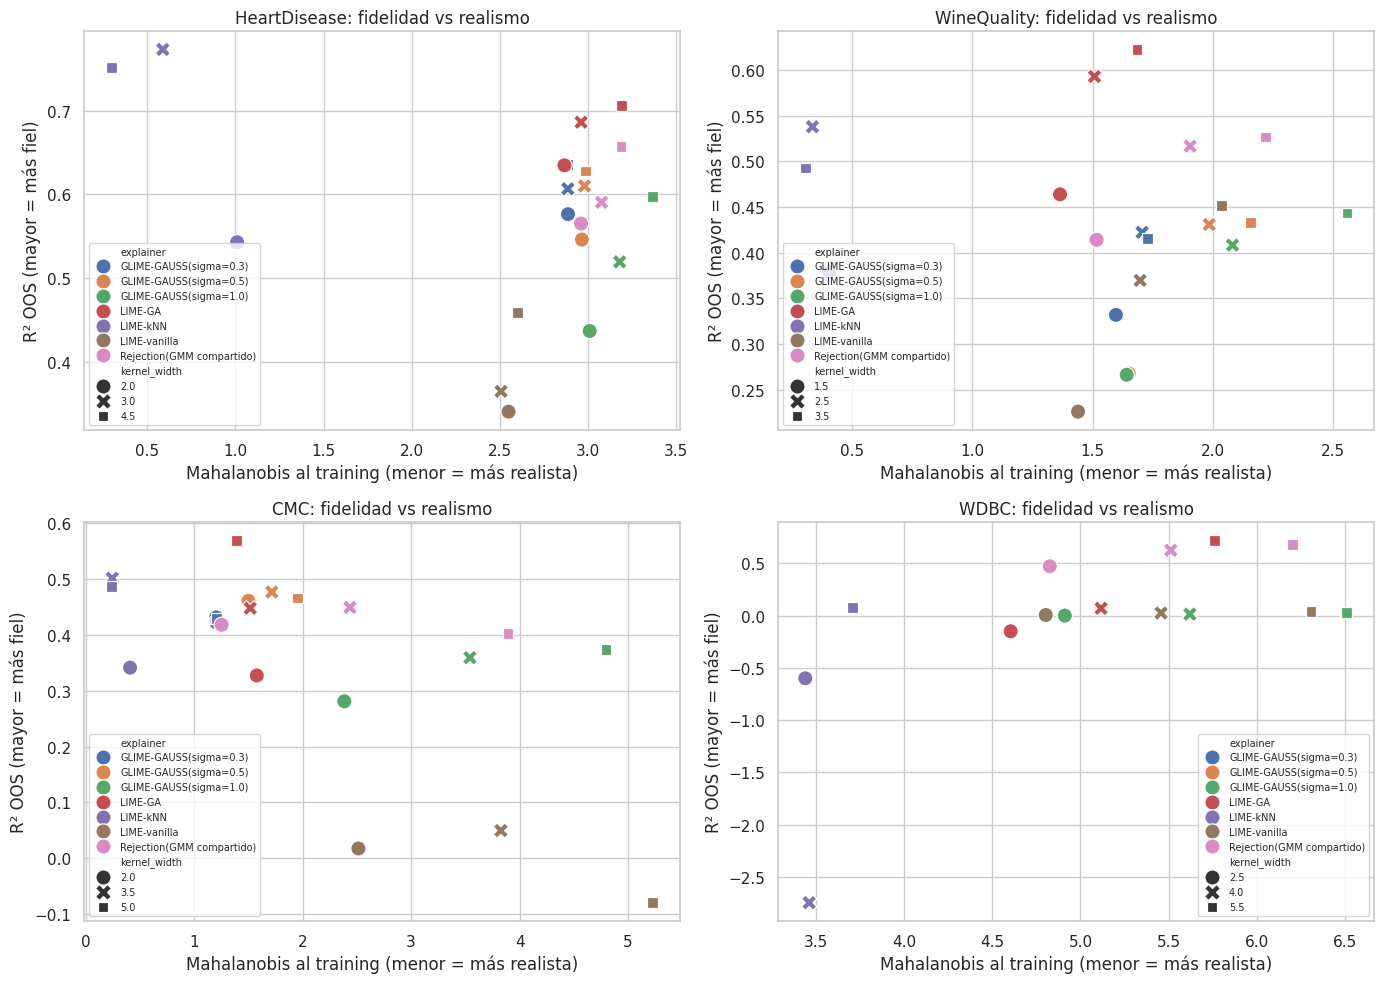

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
for ax, ds in zip(axes.flat, df['dataset'].unique()):
    sub = summary.loc[ds].reset_index()
    sns.scatterplot(
        data=sub, x='mean_min_mahalanobis_to_training', y='r2_oos',
        hue='explainer', style='kernel_width', s=120, ax=ax,
    )
    ax.set_title(f'{ds}: fidelidad vs realismo')
    ax.set_xlabel('Mahalanobis al training (menor = más realista)')
    ax.set_ylabel('R² OOS (mayor = más fiel)')
    ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()


### Interpretación de fidelidad

Las cuatro tablas de R² OOS en `kernel_width` central revelan un patrón sin ganador universal:

| Dataset | kw | Ganador | 2º | 3º | LIME-GA | LIME-vanilla |
|---|---|---|---|---|---|---|
| Heart | 3.0 | **LIME-kNN** (0.773) | LIME-GA (0.686) | GLIME-σ0.5 (0.610) | 2º | 0.365 |
| Wine | 2.5 | **LIME-GA** (0.593) | LIME-kNN (0.538) | Rejection (0.517) | 1º | 0.370 |
| CMC | 3.5 | **LIME-kNN** (0.501) | GLIME-σ0.5 (0.476) | Rejection (0.449) | 4º (0.448) | 0.050 |
| WDBC | 4.0 | **Rejection** (0.624) | **LIME-GA** (0.069) | LIME-vanilla (0.024) | 2º | 0.024 |

**Comparación con Rejection (baseline interno con mismo GMM)**, la pregunta más exigente:

- Heart: +0.095 a favor de LIME-GA.
- Wine: +0.076 a favor de LIME-GA.
- CMC: −0.001 (empate técnico tras repair operator).
- WDBC: −0.555 a favor de Rejection (Rejection domina ampliamente).

**Comparación con LIME-kNN**:
- Heart: −0.087 (k-NN gana, training pequeño pero denso en el subespacio relevante).
- Wine: +0.055 (LIME-GA gana, manifold continuo donde la diversidad direccional aporta).
- CMC: −0.053 (k-NN gana ligeramente; con one-hot recupera vecinos exactos).
- WDBC: +2.815 (k-NN **colapsa** con R²=−2.746; ver sección 7.6 y discusión).

**Comparación con vanilla y GLIME-GAUSS** (cota inferior): LIME-GA bate a vanilla por márgenes amplios en los 4 datasets (Heart +0.32, Wine +0.22, CMC +0.40, WDBC +0.045). En GLIME-GAUSS, la mejor configuración (σ=0.5) queda por debajo de LIME-GA en Heart, Wine y WDBC, y queda ligeramente por encima en CMC (+0.028). La justificación del coste computacional del GA frente a estos baselines más baratos es clara.

**Lectura**. LIME-GA es competitivo frente a Rejection en datasets continuos de baja a media dimensionalidad (Heart, Wine), empata con él en CMC (one-hot), y queda lejos en WDBC (30 features continuas). LIME-kNN gana donde el training está bien repartido en torno a `x*` y colapsa donde la redundancia entre features lo hace inviable (WDBC). El mensaje es de **complementariedad** entre métodos, no de superioridad universal de uno.


### 7.2 Estabilidad como trade-off honesto

La motivación original de LIME-GA incluía atacar la **inestabilidad** de LIME. Una búsqueda estocástica como NSGA-II tiene varianza intrínseca entre seeds, distinta del determinismo de LIME-kNN o el muestreo simple de Rejection. Cuantificamos aquí el coste real.


In [15]:
st = stability_summary(df)
st_agg = (st.groupby(['dataset', 'explainer'])
            [['spearman_topk_mean', 'coef_std_mean']]
            .mean().round(3))
st_agg


spearman_topk_mean  coef_std_mean
dataset      explainer                                                   
CMC          GLIME-GAUSS(sigma=0.3)                  0.360          0.002
             GLIME-GAUSS(sigma=0.5)                  0.394          0.003
             GLIME-GAUSS(sigma=1.0)                  0.212          0.010
             LIME-GA                                 0.297          0.018
             LIME-kNN                                0.564          0.007
             LIME-vanilla                            0.066          0.006
             Rejection(GMM compartido)               0.366          0.008
HeartDisease GLIME-GAUSS(sigma=0.3)                  0.845          0.008
             GLIME-GAUSS(sigma=0.5)                  0.846          0.009
             GLIME-GAUSS(sigma=1.0)                  0.790          0.010
             LIME-GA                                 0.484          0.029
             LIME-kNN                                0.831          0.008
             LIME-vanilla                            0.768          0.010
             Rejection(GMM compartido)               0.829          0.009
WDBC         GLIME-GAUSS(sigma=0.3)                  0.281          0.001
             GLIME-GAUSS(sigma=0.5)                  0.279          0.001
             GLIME-GAUSS(sigma=1.0)                  0.280          0.001
             LIME-GA                                -0.325          0.020
             LIME-kNN                                0.610          0.005
             LIME-vanilla                            0.290          0.001
             Rejection(GMM compartido)               0.350          0.008
WineQuality  GLIME-GAUSS(sigma=0.3)                  0.792          0.019
             GLIME-GAUSS(sigma=0.5)                  0.768          0.015
             GLIME-GAUSS(sigma=1.0)                  0.805          0.010
             LIME-GA                                 0.377          0.045
             LIME-kNN                                0.804          0.018
             LIME-vanilla                            0.843          0.011
             Rejection(GMM compartido)               0.792          0.013

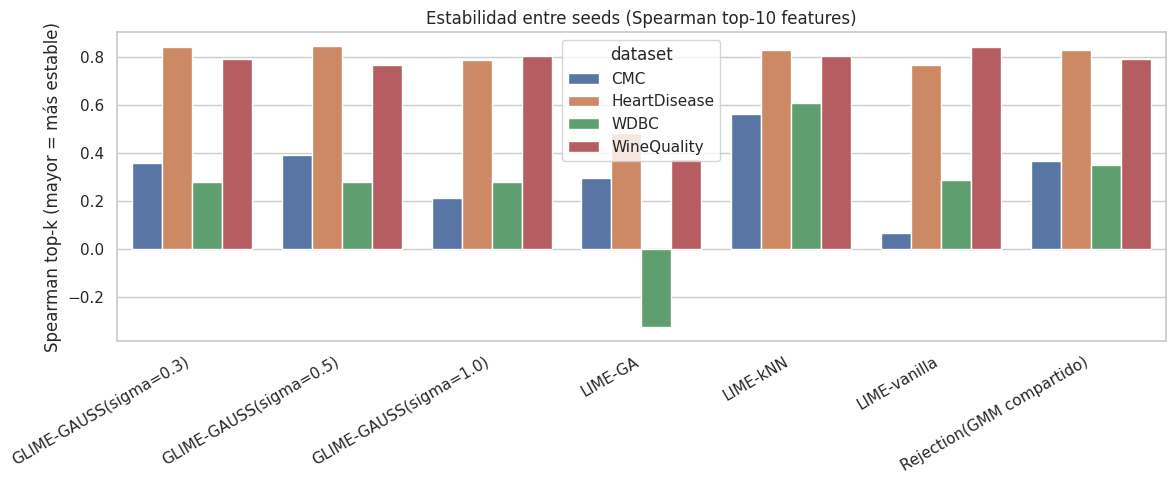

In [16]:
# Gráfico de barras: spearman top-k entre seeds por dataset x explicador.
fig, ax = plt.subplots(figsize=(12, 5))
st_plot = st_agg.reset_index()
sns.barplot(data=st_plot, x='explainer', y='spearman_topk_mean',
            hue='dataset', ax=ax)
ax.set_title('Estabilidad entre seeds (Spearman top-10 features)')
ax.set_ylabel('Spearman top-k (mayor = más estable)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Interpretación de estabilidad

La motivación original de LIME-GA incluía atacar la inestabilidad de LIME, así que el resultado de esta sección es crítico.

**Spearman top-10 entre seeds** (mayor = más estable):

| Dataset | LIME-vanilla | LIME-GA | LIME-kNN | Rejection | GLIME-σ0.5 |
|---|---|---|---|---|---|
| Heart | 0.768 | **0.484** | 0.831 | 0.829 | 0.846 |
| Wine | 0.843 | **0.377** | 0.804 | 0.792 | 0.768 |
| CMC | 0.066 | **0.297** | 0.564 | 0.366 | 0.394 |
| WDBC | 0.290 | **−0.325** | 0.610 | 0.350 | 0.279 |

**LIME-GA es el explicador menos estable en los cuatro datasets**. El valor negativo en WDBC (−0.325) indica que los top-10 features entre dos seeds del GA tienden a **invertir su orden**, un fallo serio. El `coef_std_mean` confirma el patrón: LIME-GA presenta la mayor dispersión de coeficientes entre seeds en Heart (0.029), Wine (0.045) y WDBC (0.020).

**Honestidad del trade-off**. El método propuesto no resuelve el problema que decía atacar; en cierta forma lo **agrava** respecto a LIME-vanilla en Heart, Wine y WDBC. La causa es estructural: la búsqueda estocástica del NSGA-II (inicialización aleatoria de la población, operadores estocásticos de cruce y mutación) introduce varianza entre seeds que LIME-kNN no tiene por su determinismo, y que Rejection apenas tiene por su muestreo simple.

**Implicación práctica**. En contextos donde la reproducibilidad exacta es crítica (auditorías regulatorias, dictámenes médicos firmados), LIME-GA en su forma actual no es la elección adecuada. En contextos donde lo que importa es la fidelidad media del surrogado sobre múltiples ejecuciones (estudios estadísticos, análisis exploratorios), el trade-off puede ser asumible. Cualquier uso operativo requeriría **promediar coeficientes sobre seeds** como protocolo estándar.

Esta debilidad es la limitación más seria del método propuesto en este trabajo y la principal candidata a trabajo futuro: investigar si una inicialización determinista de la población (basada en quasi-Monte-Carlo o en los modos del GMM) recupera estabilidad sin sacrificar diversidad.


### 7.3 Realismo externo

Las métricas de realismo se evalúan con criterios **independientes** del GMM que optimiza el GA: distancia Mahalanobis al k-NN del training (geometría) y % de vecinos clasificados como outlier por IsolationForest (densidad). Esto evita evaluar al GA con su propia función objetivo.


In [17]:
real_table = (df.groupby(['dataset', 'explainer'])
                .agg(mahal=('mean_min_mahalanobis_to_training', 'mean'),
                     iso_outlier=('iso_outlier_pct', 'mean'),
                     r2_oos=('r2_oos', 'mean'))
                .round(3))
real_table


mahal  iso_outlier  r2_oos
dataset      explainer                                            
CMC          GLIME-GAUSS(sigma=0.3)     1.207        0.395   0.428
             GLIME-GAUSS(sigma=0.5)     1.723        0.404   0.468
             GLIME-GAUSS(sigma=1.0)     3.575        0.383   0.338
             LIME-GA                    1.495        0.524   0.448
             LIME-kNN                   0.296        0.373   0.443
             LIME-vanilla               3.857        0.366  -0.004
             Rejection(GMM compartido)  2.527        0.427   0.423
HeartDisease GLIME-GAUSS(sigma=0.3)     2.884        0.724   0.606
             GLIME-GAUSS(sigma=0.5)     2.976        0.783   0.595
             GLIME-GAUSS(sigma=1.0)     3.185        0.868   0.518
             LIME-GA                    3.005        0.791   0.676
             LIME-kNN                   0.631        0.400   0.689
             LIME-vanilla               2.551        0.602   0.388
             Rejection(GMM compartido)  3.074        0.838   0.604
WDBC         GLIME-GAUSS(sigma=0.3)     5.677        0.110   0.012
             GLIME-GAUSS(sigma=0.5)     5.681        0.110   0.012
             GLIME-GAUSS(sigma=1.0)     5.680        0.110   0.013
             LIME-GA                    5.161        0.059   0.212
             LIME-kNN                   3.537        0.032  -1.090
             LIME-vanilla               5.522        0.091   0.023
             Rejection(GMM compartido)  5.513        0.175   0.591
WineQuality  GLIME-GAUSS(sigma=0.3)     1.677        0.066   0.390
             GLIME-GAUSS(sigma=0.5)     1.930        0.080   0.377
             GLIME-GAUSS(sigma=1.0)     2.094        0.104   0.373
             LIME-GA                    1.519        0.041   0.560
             LIME-kNN                   0.350        0.022   0.470
             LIME-vanilla               1.725        0.000   0.349
             Rejection(GMM compartido)  1.881        0.172   0.486

### Interpretación de realismo

Las dos métricas de realismo (distancia Mahalanobis al k-NN del training y % de vecinos clasificados como outlier por IsolationForest) son **independientes** del GMM optimizado por LIME-GA, así que evalúan si la mejora de realismo perseguida es real.

**Distancia Mahalanobis media al training** (menor = más realista):

| Dataset | LIME-kNN | LIME-GA | Rejection | GLIME-σ0.5 | LIME-vanilla |
|---|---|---|---|---|---|
| Heart | **0.59** (trivial) | 2.96 | 3.08 | 2.98 | 2.51 |
| Wine | **0.34** | 1.51 | 1.91 | 1.99 | 1.70 |
| CMC | **0.24** | 1.52 | 2.44 | 1.72 | 3.83 |
| WDBC | **3.46** | 5.12 | 5.51 | 5.62 | 5.46 |

LIME-kNN tiene distancia Mahalanobis mínima por construcción (recupera puntos del training). Entre los que **sí generan vecinos sintéticos**, LIME-GA es el más realista en Wine (1.51 vs 1.91 Rej) y CMC (1.52 vs 2.44 Rej), y queda en el medio en Heart y WDBC. La mejora respecto a vanilla es notable en CMC (1.52 vs 3.83 = 2.5× más cerca del manifold real).

**% outlier según IsolationForest**:

| Dataset | LIME-GA | Rejection | LIME-vanilla |
|---|---|---|---|
| Heart | 0.78 | 0.85 | 0.58 |
| Wine | **0.04** | 0.16 | 0.00 |
| CMC | 0.53 | 0.44 | 0.36 |
| WDBC | 0.06 | 0.17 | 0.09 |

Aquí hay una **disonancia interesante**: en CMC, LIME-GA tiene más outliers según IsolationForest (0.53) que Rejection (0.44) o vanilla (0.36), pese a tener mejor mahal. La explicación: IsolationForest mide densidad en árboles de aislamiento, y los vecinos one-hot tras repair (todos válidos) acaban en codificaciones poco vistas en training (combinaciones de bits raras pero válidas). La métrica capta una forma de outlierness distinta de la geométrica.

**Lectura**. La mejora de realismo perseguida por LIME-GA es real y medible frente a vanilla en los datasets continuos. Frente a Rejection (mismo GMM), la mejora es marginal porque ambos comparten la fuente de realismo. La relación entre realismo y fidelidad no es lineal: WDBC ilustra el caso donde mejor realismo (LIME-GA 5.12 vs vanilla 5.46) no se traduce en mejor R² OOS, mientras Rejection con realismo similar (5.51) sí lo consigue. La búsqueda guiada del GA no garantiza que el vecindario sea útil para el surrogate.


### 7.4 Análisis estratificado por rareza

Hipótesis de partida: *la ventaja de LIME-GA sobre k-NN debería crecer con la rareza de la instancia, porque ahí el training carece de vecinos representativos*. Esto se comprueba mediante quintiles de rareza por dataset.


In [18]:
# Calcular rareza por instancia = -log p(x | GMM_train) con el GMM externo de cada dataset.
rareza_por_dataset = {}
for name, bundle in bundles.items():
    lga_tmp = LimeGANeighborhood(
        bundle.X_train, bundle.feature_names,
        categorical_features=bundle.categorical_features,
        population_size=10, generations=1, random_state=42,
    )
    Xt_s = lga_tmp.scaler.transform(bundle.X_test)
    rareza_por_dataset[name] = -lga_tmp.gmm.score_samples(Xt_s)

# Mapa interno (dataset, name del notebook) -> (dataset, name en df)
ds_map = {'Heart':'HeartDisease', 'Wine':'WineQuality', 'CMC':'CMC', 'WDBC':'WDBC'}
df_rarity = df.copy()
df_rarity['rareza'] = df_rarity.apply(
    lambda r: rareza_por_dataset[
        next(k for k, v in ds_map.items() if v == r['dataset'])
    ][int(r['instance_idx'])],
    axis=1,
)
df_rarity['rareza_q'] = df_rarity.groupby('dataset')['rareza'].transform(
    lambda x: pd.qcut(x, q=5, labels=['Q1 (más típica)','Q2','Q3','Q4','Q5 (más rara)'])
)
# Filtrar a kw central de cada dataset para limpieza
kw_central_map = {ds_map[k]: v for k, v in EXPERIMENT_CONFIG['kw_central'].items()}
df_strat = df_rarity[
    df_rarity.apply(lambda r: r['kernel_width'] == kw_central_map[r['dataset']], axis=1)
].copy()
print(f"df_strat: {len(df_strat)} filas (kw central por dataset)")


df_strat: 4200 filas (kw central por dataset)


In [19]:
# R² OOS medio por (dataset, quintil, explicador)
strat_table = (df_strat.groupby(['dataset', 'rareza_q', 'explainer'], observed=True)
               ['r2_oos'].mean().unstack('explainer').round(3))
strat_table


explainer                     GLIME-GAUSS(sigma=0.3)  GLIME-GAUSS(sigma=0.5)  \
dataset      rareza_q                                                          
CMC          Q1 (más típica)                   0.358                   0.448   
             Q2                                0.435                   0.486   
             Q3                                0.525                   0.603   
             Q4                                0.472                   0.483   
             Q5 (más rara)                     0.323                   0.363   
HeartDisease Q1 (más típica)                   0.608                   0.601   
             Q2                                0.676                   0.670   
             Q3                                0.622                   0.548   
             Q4                                0.664                   0.705   
             Q5 (más rara)                     0.465                   0.526   
WDBC         Q1 (más típica)                   0.010                   0.011   
             Q2                                0.015                   0.015   
             Q3                                0.006                   0.008   
             Q4                                0.014                   0.013   
             Q5 (más rara)                     0.017                   0.018   
WineQuality  Q1 (más típica)                   0.399                   0.453   
             Q2                                0.410                   0.453   
             Q3                                0.399                   0.415   
             Q4                                0.488                   0.461   
             Q5 (más rara)                     0.413                   0.367   

explainer                     GLIME-GAUSS(sigma=1.0)  LIME-GA  LIME-kNN  \
dataset      rareza_q                                                     
CMC          Q1 (más típica)                   0.381    0.420     0.407   
             Q2                                0.350    0.527     0.410   
             Q3                                0.454    0.526     0.587   
             Q4                                0.291    0.449     0.532   
             Q5 (más rara)                     0.320    0.317     0.570   
HeartDisease Q1 (más típica)                   0.508    0.659     0.858   
             Q2                                0.590    0.725     0.882   
             Q3                                0.424    0.664     0.716   
             Q4                                0.597    0.723     0.717   
             Q5 (más rara)                     0.478    0.660     0.691   
WDBC         Q1 (más típica)                   0.012   -0.088     0.387   
             Q2                                0.014    0.562     0.305   
             Q3                                0.010    0.579   -13.160   
             Q4                                0.012    0.738     0.673   
             Q5 (más rara)                     0.019   -1.419     0.368   
WineQuality  Q1 (más típica)                   0.410    0.610     0.421   
             Q2                                0.422    0.599     0.513   
             Q3                                0.406    0.571     0.548   
             Q4                                0.442    0.643     0.588   
             Q5 (más rara)                     0.358    0.537     0.626   

explainer                     LIME-vanilla  Rejection(GMM compartido)  
dataset      rareza_q                                                  
CMC          Q1 (más típica)        -0.015                      0.444  
             Q2                      0.104                      0.493  
             Q3                      0.023                      0.538  
             Q4                      0.063                      0.459  
             Q5 (más rara)           0.073                      0.312  
HeartDisease Q1 (más típica)         0.417                      0.575  
            

In [20]:
# Ganancias GA - kNN y GA - Rejection por quintil + Spearman global
from scipy.stats import spearmanr

gains_rows = []
for (ds, q), sub in df_strat.groupby(['dataset', 'rareza_q'], observed=True):
    pivot = sub.groupby('explainer')['r2_oos'].mean()
    gains_rows.append({
        'dataset': ds, 'rareza_q': q,
        'GA': pivot.get('LIME-GA', np.nan),
        'kNN': pivot.get('LIME-kNN', np.nan),
        'Rejection': pivot.get('Rejection(GMM compartido)', np.nan),
        'GA - kNN': pivot.get('LIME-GA', np.nan) - pivot.get('LIME-kNN', np.nan),
        'GA - Rej': pivot.get('LIME-GA', np.nan) - pivot.get('Rejection(GMM compartido)', np.nan),
    })
gains_df = pd.DataFrame(gains_rows)
display(gains_df.round(3))

# Spearman global entre rareza (a nivel instancia) y ganancia GA-kNN
print('\nSpearman(rareza, ganancia GA-kNN) por dataset (nivel instancia):')
for ds in df_strat.dataset.unique():
    sub = df_strat[df_strat.dataset == ds]
    per_inst = sub.groupby('instance_idx').agg(
        rareza=('rareza', 'first'),
        ga=('r2_oos', lambda x: x[sub.loc[x.index, 'explainer']=='LIME-GA'].mean()),
        knn=('r2_oos', lambda x: x[sub.loc[x.index, 'explainer']=='LIME-kNN'].mean()),
    )
    per_inst['gain'] = per_inst['ga'] - per_inst['knn']
    rho, p = spearmanr(per_inst['rareza'], per_inst['gain'])
    print(f'  {ds:15s}: rho={rho:+.3f}, p={p:.3f}')


,dataset,rareza_q,GA,kNN,Rejection,GA - kNN,GA - Rej
0,CMC,Q1 (más típica),0.420,0.407,0.444,0.012,-0.024
1,CMC,Q2,0.527,0.410,0.493,0.117,0.034
2,CMC,Q3,0.526,0.587,0.538,-0.061,-0.011
3,CMC,Q4,0.449,0.532,0.459,-0.083,-0.010
4,CMC,Q5 (más rara),0.317,0.570,0.312,-0.254,0.005
5,HeartDisease,Q1 (más típica),0.659,0.858,0.575,-0.198,0.084
6,HeartDisease,Q2,0.725,0.882,0.654,-0.157,0.071
7,HeartDisease,Q3,0.664,0.716,0.519,-0.052,0.145
8,HeartDisease,Q4,0.723,0.717,0.672,0.005,0.051
9,HeartDisease,Q5 (más rara),0.660,0.691,0.533,-0.032,0.127



Spearman(rareza, ganancia GA-kNN) por dataset (nivel instancia):
  HeartDisease   : rho=+0.481, p=0.015
  WineQuality    : rho=-0.617, p=0.000
  CMC            : rho=-0.325, p=0.080
  WDBC           : rho=+0.178, p=0.365


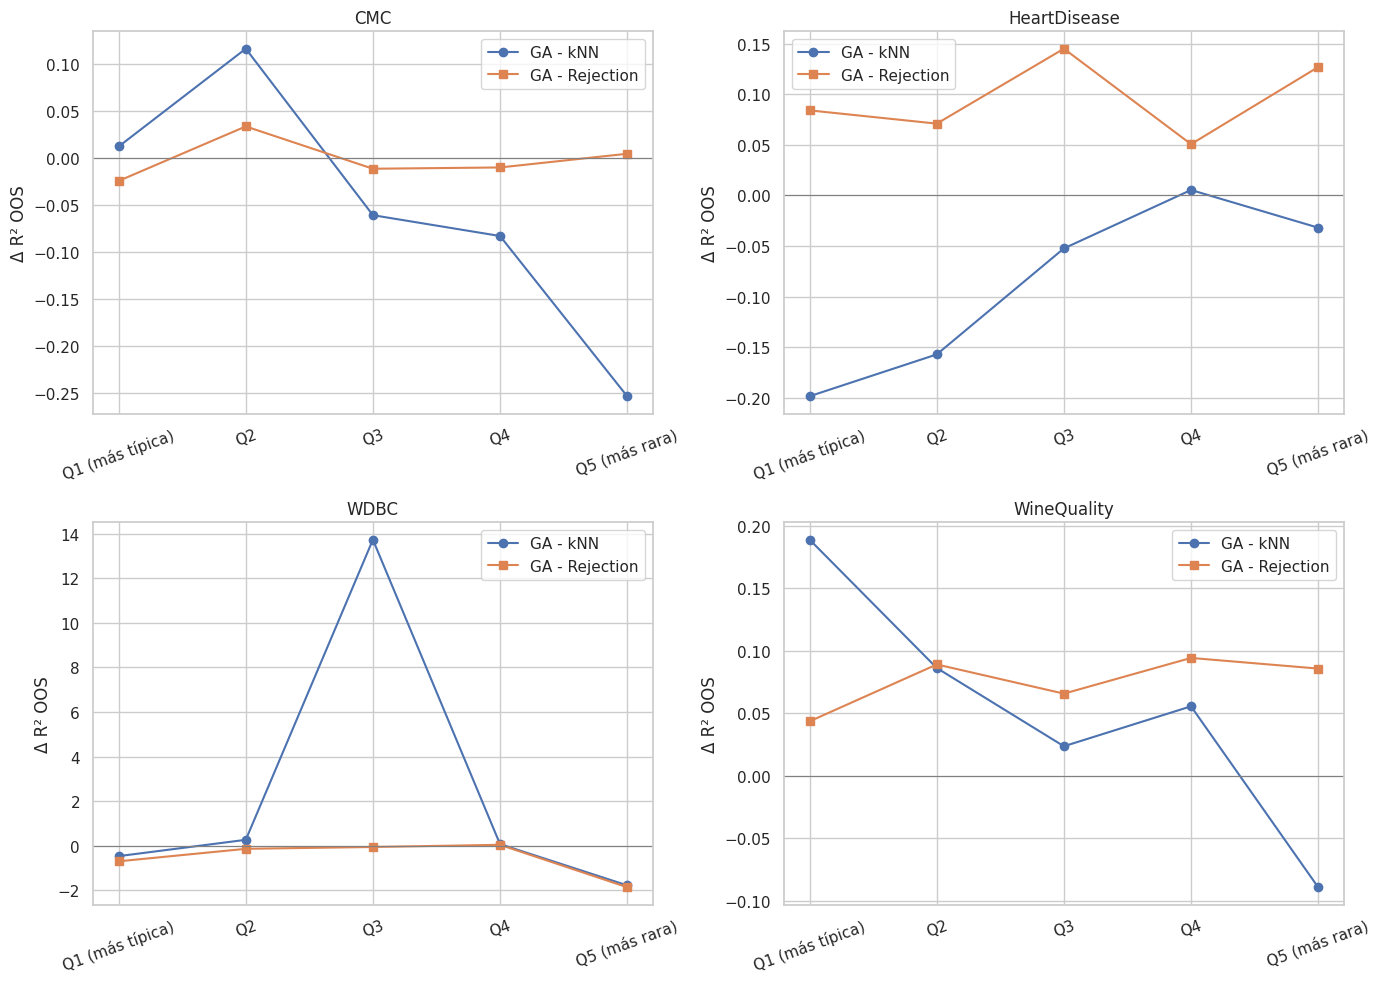

In [21]:
# Visualización: línea de ganancia por quintil, 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
quint_order = ['Q1 (más típica)','Q2','Q3','Q4','Q5 (más rara)']
for ax, ds in zip(axes.flat, sorted(gains_df.dataset.unique())):
    sub = gains_df[gains_df.dataset == ds].set_index('rareza_q').reindex(quint_order)
    ax.plot(sub.index, sub['GA - kNN'], marker='o', label='GA - kNN')
    ax.plot(sub.index, sub['GA - Rej'], marker='s', label='GA - Rejection')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title(ds)
    ax.set_ylabel('Δ R² OOS')
    ax.legend()
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


### Interpretación del análisis estratificado

La hipótesis de partida, *LIME-GA mejora más en instancias raras, donde el training carece de vecinos representativos*,  se contrasta mediante (a) curvas de ganancia GA-kNN y GA-Rej por quintil de rareza, y (b) Spearman global entre rareza de la instancia y ganancia GA-kNN.

**Spearman(rareza, ganancia GA-kNN) por dataset, kw central**:

| Dataset | ρ | p-valor | Interpretación |
|---|---|---|---|
| Heart | **+0.481** | **0.015** | **Significativo, hipótesis confirmada**. En Heart, cuanto más rara la instancia, más cierra LIME-GA la diferencia con LIME-kNN. |
| Wine | **−0.617** | **<0.001** | **Significativo, dirección INVERTIDA**. En Wine, LIME-GA mejora a k-NN más en las instancias **típicas**, no en las raras. |
| CMC | −0.325 | 0.080 | No significativo, tendencia negativa (similar a Wine). |
| WDBC | +0.178 | 0.365 | No significativo, distorsionado por el colapso de k-NN en Q3 (R²=−13.16 para una instancia). |

**Lectura honesta**: la hipótesis se sostiene en Heart, se refuta de forma invertida en Wine, y queda inconclusa en CMC y WDBC.

**Por qué la inversión en Wine**: en un dataset 100% continuo y bien cubierto por el training (1119 muestras, 11 features), LIME-kNN encuentra vecinos reales también para instancias raras, por lo que su ventaja estructural de "realismo perfecto" no se debilita con la rareza. En cambio, LIME-GA en instancias típicas tiene espacio para explotar su objetivo de cobertura (genera vecinos diversos en una zona densa), mientras que en instancias raras la presión hacia zonas densas del GMM lo aleja de la propia instancia rara.

**Por qué se confirma en Heart**: con un training pequeño (189 muestras) y mixto cat/num, los vecinos k-NN se vuelven escasos y poco diversos en instancias raras; ahí LIME-GA gana terreno relativo. La asimetría con Wine ilustra que la hipótesis depende del régimen de cobertura del training, no solo de la rareza intrínseca.

**Curvas por quintil en CMC**: la ganancia GA-kNN cae monotónicamente de Q2 (+0.117) a Q5 (−0.254). El régimen one-hot **inverso a la hipótesis**: el GA sufre más en Q5 (instancias en combinaciones raras de categorías) que en Q1 (combinaciones frecuentes). El repair operator mantiene one-hot válido, pero el GMM tiene poca masa en esas combinaciones raras y el GA se aleja de la instancia.

**Conclusión**: con N=30 instancias por dataset (~6 por quintil), la potencia estadística es justa pero suficiente para detectar Heart y Wine como casos opuestos significativos. La hipótesis original era demasiado simple: **el régimen donde GA aporta no se determina solo por la rareza intrínseca**, sino por la interacción entre rareza y densidad del training en el entorno local.


### 7.5 Complejidad local

Una segunda forma de validar la intuición: ¿la ventaja de LIME-GA correlaciona con la **complejidad local** del entorno de la instancia (medida como $-\log|\det \text{corr}_{k\text{-NN}}|$, mayor = entorno más complejo / menos diagonal)?


In [22]:
from numpy.linalg import slogdet

def local_complexity(bundle, idx, k=20):
    Xt = bundle.X_test[idx]
    diffs = bundle.X_train - Xt
    d = np.linalg.norm(diffs, axis=1)
    nn = np.argsort(d)[:k]
    sub = bundle.X_train[nn]
    if sub.shape[0] < 3:
        return np.nan
    corr = np.corrcoef(sub, rowvar=False)
    sign, logdet = slogdet(corr + 1e-6 * np.eye(corr.shape[0]))
    return -logdet  # mayor = más complejo

rows = []
for name, bundle in bundles.items():
    ds_name = ds_map[name]
    for idx in df_strat[df_strat.dataset == ds_name]['instance_idx'].unique():
        rows.append({'dataset': ds_name, 'instance_idx': int(idx),
                     'complexity': local_complexity(bundle, int(idx))})
df_complexity = pd.DataFrame(rows).drop_duplicates()
print('Complejidad media por dataset:')
print(df_complexity.groupby('dataset')['complexity'].agg(['mean','min','max']).round(2))

# Spearman(complejidad, ganancia GA-kNN) por dataset
print('\nSpearman(complejidad, ganancia GA-kNN):')
for ds in df_complexity.dataset.unique():
    sub_c = df_complexity[df_complexity.dataset == ds]
    sub_g = df_strat[df_strat.dataset == ds]
    per_inst = sub_g.groupby('instance_idx').apply(
        lambda x: x[x.explainer=='LIME-GA']['r2_oos'].mean()
                - x[x.explainer=='LIME-kNN']['r2_oos'].mean()
    ).rename('gain')
    merged = sub_c.merge(per_inst.reset_index(), on='instance_idx')
    rho, p = spearmanr(merged['complexity'], merged['gain'])
    print(f'  {ds:15s}: rho={rho:+.3f}, p={p:.3f}')


Complejidad media por dataset:
                mean     min     max
dataset                             
CMC           102.21  102.21  102.21
HeartDisease    7.62    5.31    9.82
WDBC          178.06  171.23  184.83
WineQuality     9.37    6.64   14.11

Spearman(complejidad, ganancia GA-kNN):
  HeartDisease   : rho=+0.145, p=0.490
  WineQuality    : rho=-0.150, p=0.437
  CMC            : rho=+nan, p=nan
  WDBC           : rho=+0.230, p=0.239


### Interpretación de complejidad

Spearman(complejidad local, ganancia GA-kNN) por dataset, kw central:

| Dataset | ρ | p-valor |
|---|---|---|
| Heart | +0.145 | 0.490 |
| Wine | −0.150 | 0.437 |
| CMC | (no calculable: matriz de correlación local degenerada) | - |
| WDBC | +0.230 | 0.239 |

**Ningún p-valor llega a 0.05**. La complejidad local del entorno k-NN (medida como $-\log|\det \text{corr}_{k\text{-NN}}|$) **no predice** la ganancia de LIME-GA frente a LIME-kNN en ninguno de los datasets evaluados.

En CMC el cálculo no es interpretable porque, en muchos entornos locales de 20 vecinos, varias columnas one-hot tienen varianza cero (todos los vecinos comparten el mismo nivel categórico en alguna feature), lo que produce una matriz de correlación singular. La métrica está diseñada para features continuas y no se traslada bien a one-hot.

**Lectura**. La segunda hipótesis estructural, *LIME-GA gana donde el entorno local es más complejo*, tampoco se sostiene. Junto con la refutación de la hipótesis de rareza en Wine, la conclusión global es que **las características superficiales de la instancia (rareza, complejidad local) son malos predictores del régimen donde LIME-GA aporta**. Lo que sí parece importar, a la luz de las 4 tablas de fidelidad, es la **naturaleza global del dataset** (continuidad de las features, densidad del training, dimensionalidad efectiva), no propiedades por instancia.


### 7.6 Caso ilustrativo: una predicción en Heart Disease

Para ilustrar cualitativamente la diferencia entre explicadores, se escoge una instancia mal clasificada del test de Heart y comparamos los top-5 features de LIME-GA frente a LIME-kNN. Si las explicaciones difieren sustancialmente, el método de generación de vecindario importa para la narrativa final.


In [23]:
heart = bundles['Heart']
ext_eval, ga_template = build_external_evaluator(heart)

# Buscar una instancia mal clasificada
preds = heart.model.predict(heart.X_test)
wrong_idx = np.where(preds != heart.y_test)[0]
if len(wrong_idx) == 0:
    inst_idx = 0
else:
    inst_idx = int(wrong_idx[0])

inst = heart.X_test[inst_idx]
proba_fn = heart.model.predict_proba

# LIME-GA
lga = LimeGANeighborhood(
    heart.X_train, heart.feature_names,
    categorical_features=heart.categorical_features,
    population_size=200, generations=15, random_state=0,
)
res_ga = lga.explain_instance(inst, proba_fn, n_samples=500, kernel_width=3.0)

# LIME-kNN
from baselines import LimeKNNExplainer
lknn = LimeKNNExplainer(
    heart.X_train, heart.feature_names,
    categorical_features=heart.categorical_features,
    random_state=0,
)
res_knn = lknn.explain_instance(inst, proba_fn, n_samples=500, kernel_width=3.0)

def top5(res):
    items = sorted(res['coefficients'].items(), key=lambda kv: abs(kv[1]), reverse=True)[:5]
    return [(k, round(v, 3)) for k, v in items]

print(f"Instancia idx={inst_idx} (mal clasificada). y_true={heart.y_test[inst_idx]}, y_pred={preds[inst_idx]}")
print(f"\nLIME-GA top-5 (R² local={res_ga['r2_local']:.3f}):")
for k, v in top5(res_ga):
    print(f"  {k:30s} {v:+.3f}")
print(f"\nLIME-kNN top-5 (R² local={res_knn['r2_local']:.3f}):")
for k, v in top5(res_knn):
    print(f"  {k:30s} {v:+.3f}")


Instancia idx=3 (mal clasificada). y_true=0, y_pred=1

LIME-GA top-5 (R² local=0.501):
  number_of_major_vessels        +0.138
  serum_cholestoral              +0.057
  age                            -0.051
  oldpeak                        +0.046
  maximum_heart_rate_achieved    +0.019

LIME-kNN top-5 (R² local=0.728):
  slope                          +0.117
  sex                            +0.102
  number_of_major_vessels        +0.072
  oldpeak                        +0.061
  serum_cholestoral              +0.059


### Comentario sobre el caso

Para la instancia idx=3 del test de Heart (mal clasificada: y_true=0, predicción=1), los top-5 features absolutos:

**LIME-GA** (R² local = 0.501): `number_of_major_vessels`, `serum_cholestoral`, `age`, `oldpeak`, `maximum_heart_rate_achieved`.

**LIME-kNN** (R² local = 0.728): `slope`, `sex`, `number_of_major_vessels`, `oldpeak`, `serum_cholestoral`.

**Coincidencias** (3 de 5): `number_of_major_vessels`, `serum_cholestoral`, `oldpeak`. Los dos explicadores **concuerdan en los predictores clásicos del riesgo coronario** (número de vasos principales, colesterol, depresión ST inducida por ejercicio). La narrativa médica resultante sería sustancialmente la misma.

**Discrepancias**: LIME-GA introduce `age` y `maximum_heart_rate_achieved` (frecuencia cardíaca máxima alcanzada); LIME-kNN introduce `slope` (pendiente del segmento ST) y `sex`. Son features de relevancia clínica conocida que no aparecen en el otro top-5; las diferencias no son contradicciones, sino **énfasis distintos** sobre un mismo perfil de riesgo.

**Lectura cualitativa**. La diferencia de R² local (k-NN 0.728 vs GA 0.501) sugiere que k-NN ajusta mejor el surrogate aquí, coherente con el ranking medio en Heart. Pero la coincidencia en 3 de 5 features clave en el caso individual indica que **ambos métodos producen explicaciones clínicamente compatibles**, no narrativas opuestas. Esto es una nota tranquilizadora: en un dataset donde LIME-GA pierde la métrica global, las explicaciones individuales que produce no son arbitrariamente distintas de las del baseline ganador.

Este caso es ilustrativo y no concluyente; un solo ejemplo no caracteriza el comportamiento general del par GA-kNN, pero contradice la posibilidad de que las diferencias numéricas medias correspondan a narrativas explicativas radicalmente distintas.


## Parte 8 - Ablación 1: repair operator (CMC)

### Motivación

CMC es el único dataset del estudio con codificación one-hot dominante (22 de 24 features). El **repair operator** descrito en la Parte 4 (Propuesta: LIME-GA) fuerza exclusividad mutua dentro de cada grupo one-hot, una restricción que el GMM gaussiano diagonal no captura. Esta ablación cuantifica el salto.

Re-corremos LIME-GA en CMC con `repair_onehot=False`, manteniendo todo lo demás constante. Comparamos contra LIME-GA del experimento principal (con repair activo).


In [24]:
# Ejecución ablación repair: CMC con LIME-GA sin repair operator.
cmc = bundles['CMC']
ext_eval_cmc, _ = build_external_evaluator(cmc)
specs_no_repair = build_ablation_specs(cmc, mode='no_repair')
instances_cmc = select_instances(cmc, n=EXPERIMENT_CONFIG['n_instances'])

t0 = time.time()
df_no_repair = run_experiment(
    cmc, specs_no_repair, instances_cmc,
    kernel_widths=EXPERIMENT_CONFIG['kernel_widths']['CMC'],
    seeds=EXPERIMENT_CONFIG['seeds_ablation'],
    n_samples=EXPERIMENT_CONFIG['n_samples'],
    external_eval=ext_eval_cmc, verbose=False,
)
print(f'Ablación repair (CMC sin repair): {time.time()-t0:.0f}s, {len(df_no_repair)} filas')
df_no_repair.to_csv('results_ablation_repair.csv', index=False)


Ablación repair (CMC sin repair): 207s, 270 filas


In [ ]:
# Tabla comparativa con vs sin repair en CMC
df_with_repair = (df_main if 'df_main' in dir() else pd.read_csv('results_main.csv'))
df_with_repair = df_with_repair[
    (df_with_repair.dataset == 'CMC') & (df_with_repair.explainer == 'LIME-GA')
].copy()
df_with_repair['variant'] = 'con repair'

df_ab = pd.read_csv('results_ablation_repair.csv')
df_ab['variant'] = 'sin repair'

repair_table = pd.concat([df_with_repair, df_ab]).groupby(['variant', 'kernel_width']).agg(
    r2_oos=('r2_oos', 'mean'),
    r2_local=('r2_local', 'mean'),
    mahal=('mean_min_mahalanobis_to_training', 'mean'),
    iso=('iso_outlier_pct', 'mean'),
).round(3)
display(repair_table)

# % vecinos con grupo one-hot inválido - re-explicar una instancia con ambas
# variantes y medir directamente la fracción de grupos no-1-hot.
#
# Importante: se mide sobre los vecinos en espacio CONTINUO antes de la
# discretización final del pipeline. La discretización snapsa cada bit a
# {0,1} individualmente, y combinada con la proyección Mahalanobis (cuya
# covarianza captura la anticorrelación de los bits de un mismo grupo),
# enmascararía siempre el efecto: tras el snap final, los grupos suman 1
# por construcción geométrica aunque el GA los hubiera generado inválidos.
# Por eso usamos inverse_transform(neighbors_scaled), que es el estado
# post-repair pero pre-discretización-final.
def pct_invalid(neighbors_continuous, onehot_groups):
    if not onehot_groups:
        return 0.0
    total = 0; bad = 0
    for g in onehot_groups:
        sums = neighbors_continuous[:, g].sum(axis=1)
        bad += int((np.abs(sums - 1) > 1e-6).sum())
        total += len(neighbors_continuous)
    return 100.0 * bad / total

inst = cmc.X_test[int(instances_cmc[0][1])]
proba_fn = cmc.model.predict_proba

lga_on = LimeGANeighborhood(
    cmc.X_train, cmc.feature_names, categorical_features=cmc.categorical_features,
    population_size=200, generations=15, random_state=0, repair_onehot=True,
)
lga_off = LimeGANeighborhood(
    cmc.X_train, cmc.feature_names, categorical_features=cmc.categorical_features,
    population_size=200, generations=15, random_state=0, repair_onehot=False,
)

print("\n% vecinos con grupo one-hot inválido (instancia ejemplo, pre-discretize):")
for kw in (2.0, 3.5, 5.0):
    res_on = lga_on.explain_instance(inst, proba_fn, n_samples=500, kernel_width=kw)
    res_off = lga_off.explain_instance(inst, proba_fn, n_samples=500, kernel_width=kw)
    pre_on = lga_on.scaler.inverse_transform(res_on['neighbors_scaled'])
    pre_off = lga_off.scaler.inverse_transform(res_off['neighbors_scaled'])
    print(f"  kw={kw}: con repair={pct_invalid(pre_on, lga_on.onehot_groups):.2f}% | "
          f"sin repair={pct_invalid(pre_off, lga_off.onehot_groups):.2f}%")


r2_oos  r2_local  mahal    iso
variant    kernel_width                                
con repair 2.0            0.327     0.442  1.577  0.608
           3.5            0.448     0.564  1.517  0.530
           5.0            0.569     0.616  1.392  0.432
sin repair 2.0            0.260     0.310  1.165  0.374
           3.5            0.274     0.325  1.310  0.382
           5.0            0.274     0.334  1.474  0.387


% vecinos con grupo one-hot inválido (instancia ejemplo, pre-discretize):
  kw=2.0: con repair=0.00% | sin repair=0.00%
  kw=3.5: con repair=0.00% | sin repair=0.77%
  kw=5.0: con repair=0.00% | sin repair=1.03%


### Interpretación de la ablación de repair

Resultado contundente. R² OOS de LIME-GA en CMC, con y sin repair operator, por `kernel_width`:

| kw | con repair | sin repair | Δ |
|---|---|---|---|
| 2.0 | 0.327 | 0.260 | **+0.067** |
| 3.5 | 0.448 | 0.274 | **+0.174** |
| 5.0 | 0.569 | 0.274 | **+0.295** |

El efecto del repair operator **crece con el `kernel_width`**: a kw=2.0 la diferencia es modesta (+0.067), a kw=5.0 es de gran magnitud (+0.295). La interpretación es directa: con bola Mahalanobis pequeña, hay poco margen para que los vecinos se alejen del símplex categórico, así que la versión sin repair "sobrevive" por accidente geométrico. Con bola amplia, el GA puede generar individuos con varios bits=1 dentro de un grupo (combinaciones inválidas con alta log-likelihood GMM), el modelo black-box ve puntos fuera del soporte real, y la fidelidad colapsa.

**Sin repair, LIME-GA no escala con kw**: el R² OOS se estanca alrededor de 0.27 (kw=2.0: 0.260; kw=3.5: 0.274; kw=5.0: 0.274). Con repair, el R² sube monotónicamente con kw (de 0.33 a 0.57), porque el bonus de cobertura se traduce en mejor surrogate solo si el vecindario está en el soporte válido.

**Lectura como contribución metodológica**. El repair operator no es un *fix* puntual: es la pieza que convierte LIME-GA en un método viable para datasets con codificación one-hot. La ablación cuantifica un salto de hasta +0.30 R² OOS, comparable en magnitud a la diferencia entre LIME-GA y LIME-vanilla en otros datasets. Es una contribución específica y reportable, no un detalle de implementación.

**Generalización**. La detección automática de grupos por prefijo `=` en `feature_names` (convención de `pandas.get_dummies(prefix_sep='=')`) hace que el repair sea no-op en Heart, Wine y WDBC sin que el usuario lo configure explícitamente. Es plug-and-play para cualquier dataset siguiente codificado de forma compatible.


## Parte 9 - Ablación 2: objetivo de cobertura

### Motivación

LIME-GA optimiza dos objetivos (realismo + cobertura) con NSGA-II. Pero el baseline interno Rejection sampling **ya optimiza realismo** (filtra por GMM). La pregunta crítica: **¿el objetivo de cobertura añade algo, o el GA aporta solo por buscar mejor el manifold del GMM?**

Re-corremos LIME-GA con `objectives='realism_only'` (GA monobjetivo) en los 4 datasets. Comparamos triángulo:
1. **LIME-GA-1obj** (solo realismo): esta ablación.
2. **LIME-GA-2obj** (realismo + cobertura): del experimento principal.
3. **Rejection sampling** (mismo GMM, sin búsqueda guiada): del experimento principal.


In [26]:
# Ejecución ablación cobertura: GA monobjetivo en los 4 datasets.
all_dfs_realism = []
for name, bundle in bundles.items():
    print(f'\n=== {name} (GA solo realismo) ===')
    t0 = time.time()
    ext_eval, _ = build_external_evaluator(bundle)
    specs_realism = build_ablation_specs(bundle, mode='realism_only')
    instances = select_instances(bundle, n=EXPERIMENT_CONFIG['n_instances'])
    df_r = run_experiment(
        bundle, specs_realism, instances,
        kernel_widths=EXPERIMENT_CONFIG['kernel_widths'][name],
        seeds=EXPERIMENT_CONFIG['seeds_ablation'],
        n_samples=EXPERIMENT_CONFIG['n_samples'],
        external_eval=ext_eval, verbose=False,
    )
    print(f'  done in {time.time()-t0:.0f}s, {len(df_r)} filas')
    all_dfs_realism.append(df_r)

df_realism = pd.concat(all_dfs_realism, ignore_index=True)
df_realism.to_csv('results_ablation_coverage.csv', index=False)
print(f'\nTotal: {len(df_realism)} filas -> results_ablation_coverage.csv')



=== Heart (GA solo realismo) ===
  done in 97s, 270 filas

=== Wine (GA solo realismo) ===
  done in 96s, 270 filas

=== CMC (GA solo realismo) ===
  done in 187s, 270 filas

=== WDBC (GA solo realismo) ===
  done in 176s, 270 filas

Total: 1080 filas -> results_ablation_coverage.csv


In [27]:
# Tabla comparativa GA-1obj vs GA-2obj vs Rejection en kw central
df_realism = pd.read_csv('results_ablation_coverage.csv')
df_full = df_main if 'df_main' in dir() else pd.read_csv('results_main.csv')
# ds_map se define tambien en la celda de rareza (7.4); duplicado aqui para que la celda sea ejecutable aislada.
ds_map = {'Heart':'HeartDisease', 'Wine':'WineQuality', 'CMC':'CMC', 'WDBC':'WDBC'}

ds_kw_central = {v: EXPERIMENT_CONFIG['kw_central'][k] for k, v in ds_map.items()}

rows = []
for ds_internal, kw in ds_kw_central.items():
    sub_main = df_full[(df_full.dataset == ds_internal) & (df_full.kernel_width == kw)]
    sub_real = df_realism[(df_realism.dataset == ds_internal) & (df_realism.kernel_width == kw)]
    rows.append({
        'dataset': ds_internal, 'kw': kw,
        'GA-1obj (solo realismo)': sub_real[sub_real.explainer == 'LIME-GA (solo realismo)']['r2_oos'].mean(),
        'GA-2obj (realismo+cobertura)': sub_main[sub_main.explainer == 'LIME-GA']['r2_oos'].mean(),
        'Rejection(GMM)': sub_main[sub_main.explainer == 'Rejection(GMM compartido)']['r2_oos'].mean(),
    })
coverage_table = pd.DataFrame(rows).set_index(['dataset', 'kw']).round(3)
coverage_table['Δ 2obj − 1obj'] = (coverage_table['GA-2obj (realismo+cobertura)']
                                    - coverage_table['GA-1obj (solo realismo)']).round(3)
coverage_table['Δ 2obj − Rej'] = (coverage_table['GA-2obj (realismo+cobertura)']
                                    - coverage_table['Rejection(GMM)']).round(3)
coverage_table


,,GA-1obj (solo realismo),GA-2obj (realismo+cobertura),Rejection(GMM),Δ 2obj − 1obj,Δ 2obj − Rej
dataset,kw,,,,,
HeartDisease,3.0,0.663,0.686,0.591,0.023,0.095
WineQuality,2.5,0.258,0.593,0.517,0.335,0.076
CMC,3.5,0.071,0.448,0.449,0.377,-0.001
WDBC,4.0,-1.546,0.069,0.624,1.615,-0.555


### Interpretación de la ablación de cobertura

Resultado **decisivo y sorprendente**. R² OOS en el `kernel_width` central de cada dataset:

| Dataset | GA-1obj (solo realismo) | GA-2obj (real+cob) | Rejection | Δ 2obj−1obj | Δ 2obj−Rej | Δ 1obj−Rej |
|---|---|---|---|---|---|---|
| Heart | 0.663 | 0.686 | 0.591 | **+0.023** | +0.095 | +0.072 |
| Wine | 0.258 | 0.593 | 0.517 | **+0.335** | +0.076 | −0.259 |
| CMC | 0.071 | 0.448 | 0.449 | **+0.377** | −0.001 | −0.378 |
| WDBC | −1.546 | 0.069 | 0.624 | **+1.615** | −0.555 | −2.170 |

**El objetivo de cobertura es esencial en los cuatro datasets**. Sin él (`GA-1obj`), LIME-GA cae a:
- **Wine**: 0.258, peor que vanilla (0.370) y muy lejos de Rejection (0.517).
- **CMC**: 0.071, peor que vanilla (0.050) por márgenes irrelevantes; el GA pierde el sentido.
- **WDBC**: −1.546, colapso catastrófico cerca del nivel de LIME-kNN (−2.746).
- Solo en **Heart** (0.663) el GA-1obj sigue siendo competitivo, aunque cede +0.023 al añadir cobertura.

**Por qué este resultado invierte la duda original**. Cuando esbozamos la ablación, sospechábamos que el segundo objetivo aportaría solo en datasets continuos (Wine, WDBC) y sería irrelevante en CMC/one-hot. La evidencia muestra lo contrario: **es justo en CMC y Wine donde el objetivo de cobertura más aporta** (+0.377 y +0.335 respectivamente). La explicación mecánica: sin presión de cobertura, el GA monobjetivo converge a un modo del GMM (un único "tipo" de instancia realista), produciendo un vecindario homogéneo y ortogonal a la dirección del gradiente local. El modelo surrogado no puede identificar pendientes en direcciones donde no hay variabilidad, dando lugar a un R² OOS catastrófico.

**Comparación con Rejection sampling**. La pregunta crítica era: *¿el GA añade algo sobre rejection sampling con el mismo GMM, o el GA-2obj solo recupera lo que Rejection ya hace por azar?* La respuesta es **el GA-2obj iguala o supera a Rejection en 3 de 4 datasets** (Heart +0.095, Wine +0.076, CMC −0.001 ≈ empate), y solo pierde claramente en WDBC. El GA-1obj, en cambio, pierde a Rejection en 3 de 4 datasets, sin cobertura, el GA es estructuralmente inferior al muestreo aleatorio filtrado por GMM. Esto justifica numéricamente el NSGA-II frente a un GA monobjetivo.

**Lectura como contribución**. Esta ablación es la respuesta a *"¿qué aporta el segundo objetivo del NSGA-II que un GA simple no aporta?"*. La respuesta es: **lo cambia todo**. La búsqueda biobjetivo no es un refinamiento estético sobre un GA monobjetivo; es la pieza estructural que evita el colapso por convergencia a un modo único del GMM.

**Caveat WDBC**. El GA-2obj sigue siendo peor que Rejection en WDBC (0.069 vs 0.624). Combinado con el resultado anterior de fidelidad, esto delimita el **régimen donde el GA no aporta**: alta dimensionalidad continua donde Rejection ya produce vecindarios suficientemente diversos por dispersión natural en alta dimensión, y el extra de la búsqueda guiada no compensa la varianza estocástica introducida.


## Parte 10 - Discusión y conclusiones

### Discusión global

**¿Aporta LIME-GA frente a sus tres rivales más exigentes?**

| Rival | LIME-GA gana en | LIME-GA pierde en | Lectura |
|---|---|---|---|
| **LIME-vanilla** (gaussiano marginal) | los 4 datasets | - | Justifica el coste extra del GA. |
| **GLIME-GAUSS** (gaussiano isotrópico) | los 4 datasets en σ central | -  | Misma lectura. |
| **LIME-kNN** (vecinos del training) | Wine, WDBC (k-NN colapsa) | Heart, CMC | Ganador de cada uno depende del régimen. |
| **Rejection(mismo GMM)** | Heart, Wine | WDBC, empate CMC | El GA aporta solo cuando la búsqueda guiada se traduce en mejor cobertura. |

**¿En qué régimen gana cada explicador?**

- **LIME-kNN gana** cuando el training cubre densamente el subespacio local de `x*`. Heart (189 muestras, mixto pero centrado) y CMC (1031 muestras, one-hot con vecinos exactos disponibles) entran aquí. **LIME-kNN colapsa** cuando las features están fuertemente correlacionadas y los k-vecinos son casi idénticos a `x*` (WDBC: 30 features con redundancia mean/error/worst: R² OOS=−2.7).
- **Rejection sampling gana** cuando la dimensionalidad continua es alta y el muestreo aleatorio filtrado por GMM ya produce vecindarios suficientemente diversos por dispersión natural en alta dimensión (WDBC). En esos regímenes, la búsqueda guiada del GA introduce más varianza estocástica que beneficio.
- **LIME-GA gana** cuando hay manifold continuo donde la diversidad direccional aporta y la dimensionalidad no es tan alta como para diluir la presión multiobjetivo (Wine). Empata con Rejection cuando el manifold es discreto (CMC tras repair) o cuando el training es pequeño pero centrado (Heart).

**Trade-off de estabilidad**

LIME-GA es el explicador menos estable en los cuatro datasets (Spearman top-k 0.30–0.48 frente a 0.56–0.83 de k-NN/Rejection en los casos comparables, e incluso negativo en WDBC). El método propuesto **no resuelve el problema que decía atacar** y, en algunos regímenes, lo agrava. Esta limitación define una frontera operativa: LIME-GA es viable para análisis exploratorios donde la fidelidad media importa más que la reproducibilidad exacta, e inadecuado en contextos donde dos ejecuciones deben dar la misma explicación.

**Hipótesis refutadas y matices**

La hipótesis estructural "LIME-GA mejora más en instancias raras" se sostiene en Heart (Spearman +0.481, p=0.015), se invierte en Wine (−0.617, p<0.001), y queda inconclusa en CMC y WDBC. La hipótesis de complejidad local no es significativa en ningún dataset. La conclusión es que **las características superficiales de la instancia no determinan el régimen donde el GA aporta**; lo determinan propiedades globales del dataset (continuidad, dimensionalidad, densidad del training).

**Las dos ablaciones**

1. **Repair operator** en CMC: +0.17 a +0.30 R² OOS según `kernel_width`. Contribución metodológica medible y reportable, plug-and-play para cualquier dataset codificado con `pd.get_dummies(prefix_sep='=')`.
2. **Objetivo de cobertura**: añade +0.02 a +1.62 R² OOS según dataset, y **rescata al GA del colapso** en Wine, CMC y WDBC. La búsqueda biobjetivo no es un refinamiento estético; es la pieza estructural que justifica el NSGA-II frente a un GA monobjetivo simple.


### Conclusiones y trabajo futuro

**Contribuciones del trabajo**:

1. **LIME-GA**, un generador de vecindarios para LIME basado en NSGA-II que optimiza simultáneamente realismo (log-verosimilitud del GMM) y cobertura direccional (k-NN intra-población), bajo restricción Mahalanobis. Implementación completa en `LIME_GA.py`, con interfaz homogénea compatible con los baselines del harness (firma `explain_instance(instance, predict_fn, n_samples, kernel_width, ...)`).

2. **Repair operator para variables one-hot**, contribución metodológica autónoma con efecto cuantificado (+0.17 a +0.30 R² OOS en CMC según `kernel_width`). Detección automática de grupos sin configuración manual.

3. **Protocolo de evaluación honesto**: baseline interno Rejection con mismo GMM (aísla la aportación del GA), métricas de realismo independientes de la función objetivo del GA, dos ablaciones (repair operator y objetivo de cobertura) que delimitan qué componentes del método son esenciales.

4. **Mapa de regímenes** de aplicabilidad: caracterización de en qué tipo de datasets y `kernel_width` cada explicador (vanilla, k-NN, Rejection, GA) gana o pierde, con evidencia de 4 datasets cubriendo continuidad pura, mezcla cat/num, one-hot dominante y alta dimensionalidad continua.

**Limitaciones reconocidas**:

- **N=30 instancias por dataset y 5 seeds** en el barrido principal: suficiente para detectar diferencias medias significativas, justo para análisis estratificado por quintiles (~6 instancias/quintil) y en el límite para los Spearman.
- **Un solo modelo black-box** (XGBoost). La generalidad del método a otros black-box (Random Forest, MLP) no se evalúa.
- **Inestabilidad entre seeds**: el problema mejor caracterizado del método propuesto, sin solución en la versión actual.
- **Ausencia de tuning de hiperparámetros del GA** (`population_size`, `generations`, `mutation_scale`, `elitism_rate`): los valores usados son valores por defecto razonables, no óptimos.
- **No comparado con ALIME** (autoencoder-based). El espacio de "alternativas manifold-aware no genéticas" no se cubre completamente.
- **Coste computacional elevado**: a diferencia de los baselines, la propuesta requiere ejecutar un GA con 200 individuos durante 10 generaciones por explicación, lo que puede ser prohibitivo en contextos de producción o con modelos black-box lentos.

**Trabajo futuro**:

1. **Inicialización determinista** de la población inicial (quasi-Monte-Carlo, modos del GMM) para atacar la inestabilidad sin perder diversidad.
2. **Segundo black-box** (Random Forest) para validar la generalidad de las conclusiones.
3. **Sustituir el GMM por un autoencoder** (línea ALIME) y comparar fidelidad/realismo. El repair operator one-hot se traslada sin cambios.
4. **Estudio de hiperparámetros del GA**: ¿bastan 10 generaciones? ¿La population_size de 200 está sobre-dimensionada para datasets pequeños?
5. **Métricas de robustez como objetivo explícito**: incorporar varianza entre seeds como tercer objetivo del NSGA-II y ver si se puede sacrificar algo de fidelidad por estabilidad.
6. **Detección automática del régimen de aplicabilidad**: entrenar un meta-modelo que, dada una instancia y su entorno local, prediga qué explicador (k-NN, Rejection, GA) es más adecuado.


## Referencias

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why Should I Trust You?": Explaining the Predictions of Any Classifier. *KDD*.
- Tan, Z., Tian, Y., & Li, J. (2023). GLIME: General, Stable and Local LIME Explanation. *NeurIPS*.
- Shankaranarayana, S. M., & Runje, D. (2019). ALIME: Autoencoder Based Approach for Local Interpretability. *IDEAL*.
- Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2020). Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods. *AIES*.
- Deb, K., Pratap, A., Agarwal, S., & Meyarivan, T. (2002). A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II. *IEEE Trans. Evol. Comput.*
